# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

## 0. Install & Import Dependencies

In [1]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [2]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 1.2,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [5]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """x: (B, T, F)"""
        out, _ = self.lstm(x)        # (B, T, H)
        last   = out[:, -1, :]       # (B, H)
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

## 0. Install & Import Dependencies

In [ ]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [ ]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 1.2,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [ ]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.layer_norm = nn.LayerNorm(hidden)

    def forward(self, x):
        """x: (B, T, F)"""
        # out, _ = self.lstm(x)        # (B, T, H)
        # last   = out[:, -1, :]       # (B, H)
        out, _ = self.lstm(x)
        last = self.layer_norm(out[:, -1, :])
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


In [ ]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [ ]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)
        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662


# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

## 0. Install & Import Dependencies

In [ ]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [ ]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 1.2,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [ ]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """x: (B, T, F)"""
        out, _ = self.lstm(x)        # (B, T, H)
        last   = out[:, -1, :]       # (B, H)
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


In [ ]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [ ]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)
        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662



📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


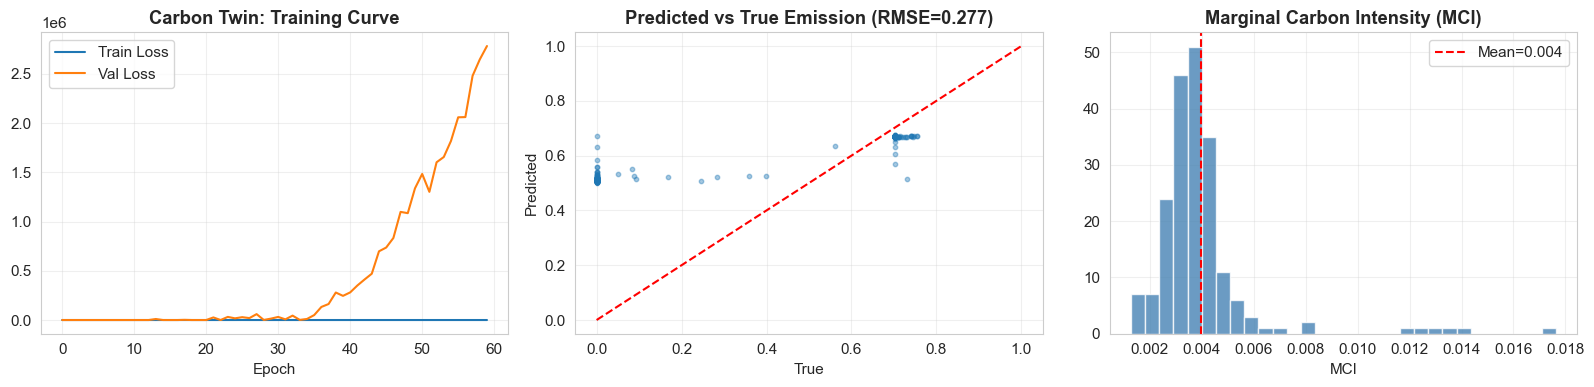

💾 Saved: 01_carbon_twin.png


In [ ]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [ ]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

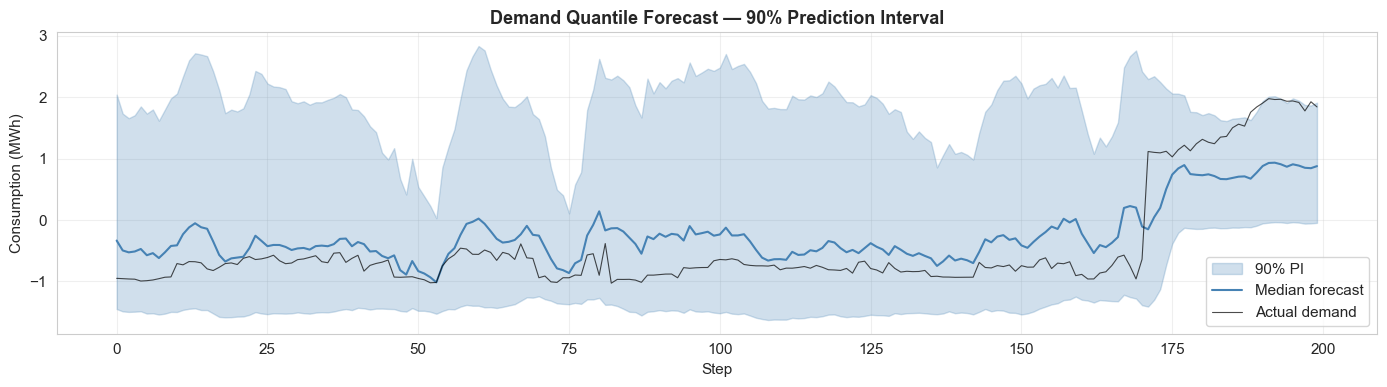

💾 Saved: 02_quantile_forecast.png


In [ ]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [ ]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        if self.verbose:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}  "
                f"budget={self.env_ref.shortage_budget:.3f}"
            )

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [ ]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [ ]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [ ]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

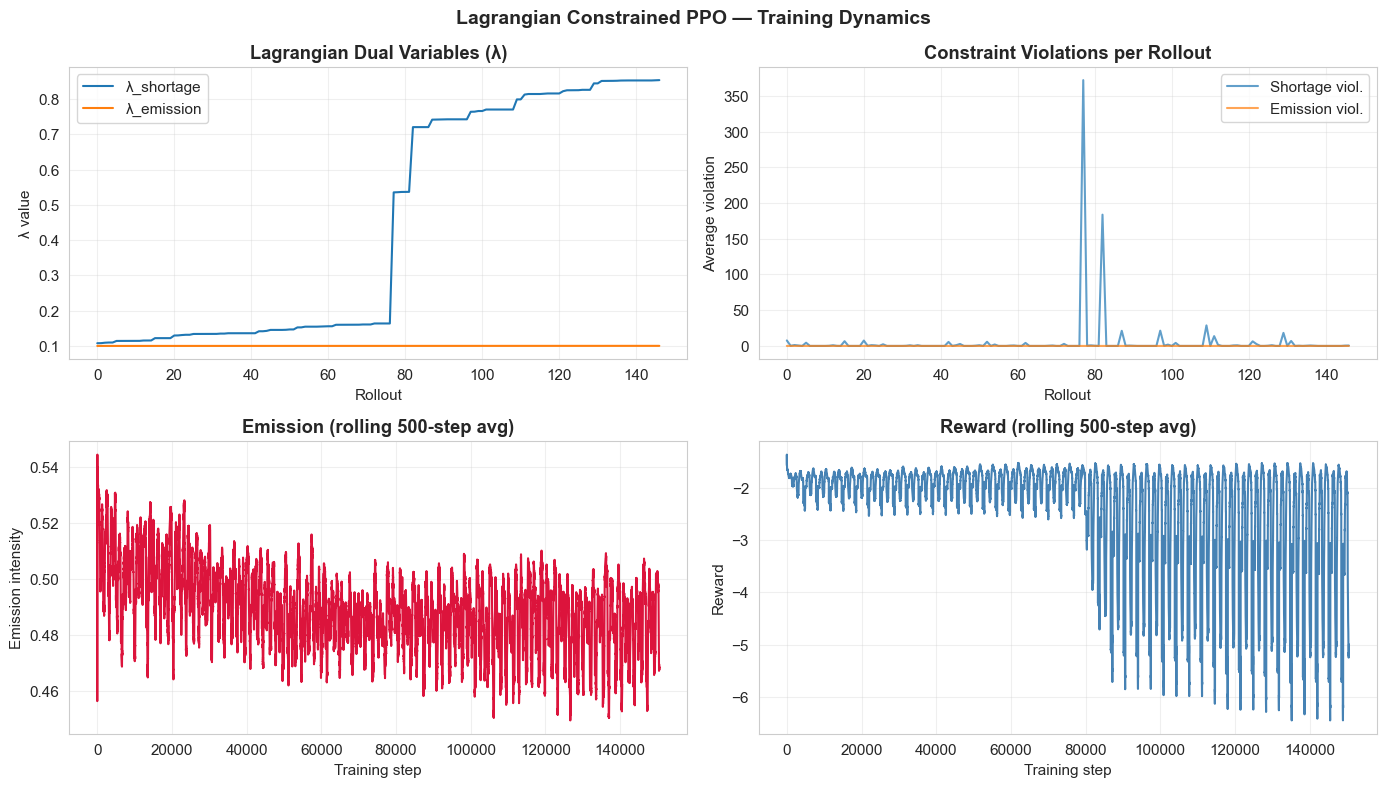

💾 Saved: 03_lagrangian_training.png


In [ ]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            g['score'] = g['emission'] * 10000   # scale
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [ ]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


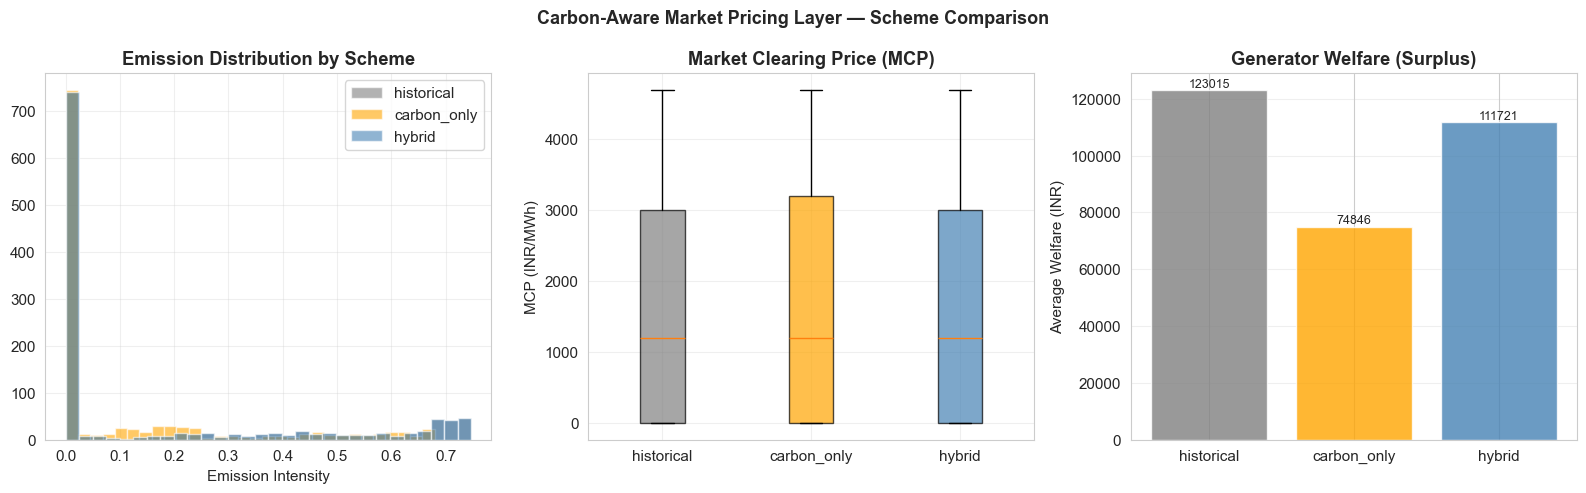

💾 Saved: 04_market_pricing.png


In [ ]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [ ]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [ ]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [ ]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


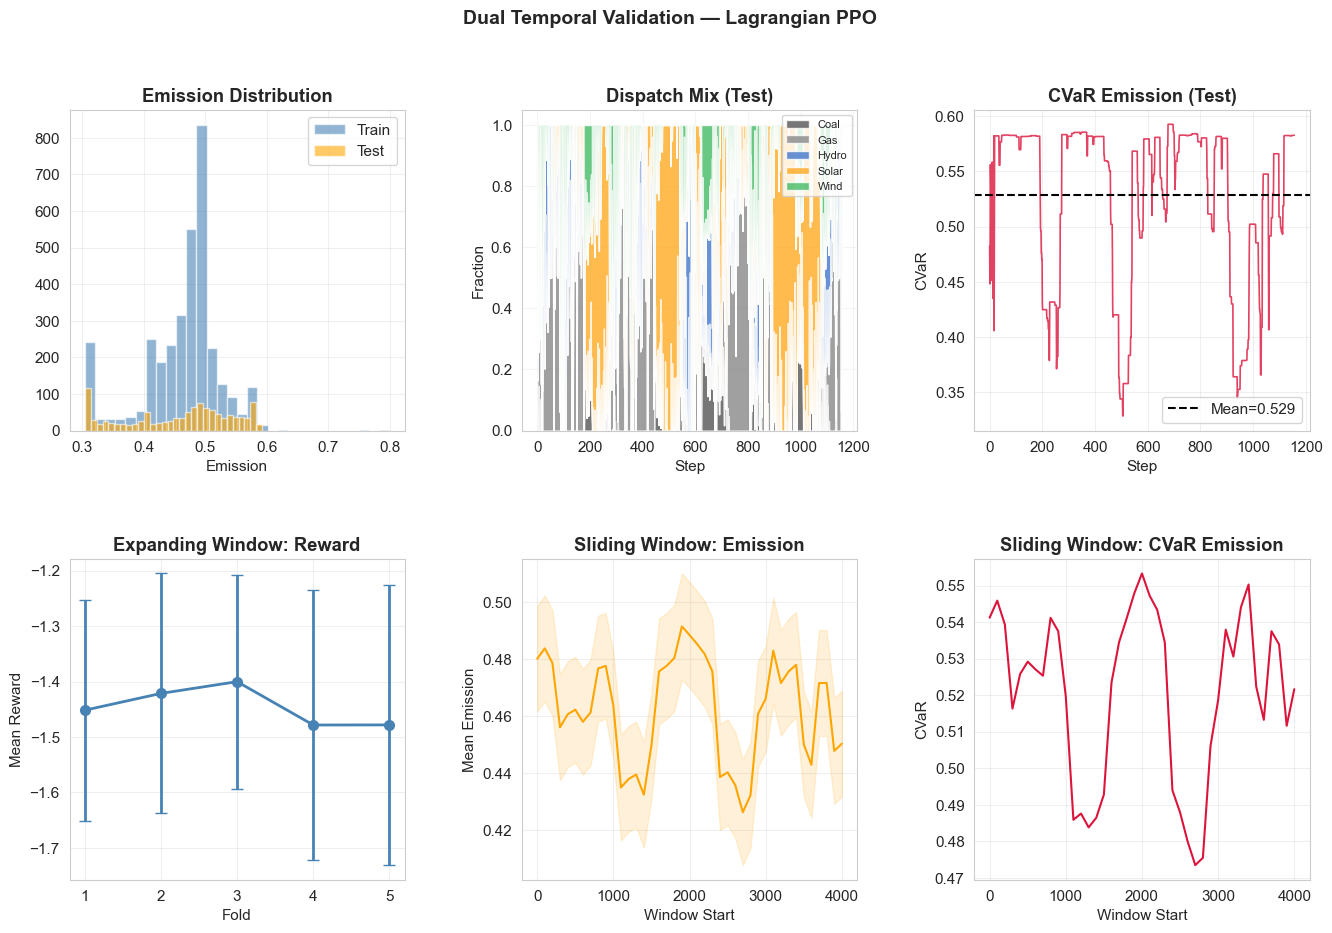

💾 Saved: 05_dual_temporal_validation.png


In [ ]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

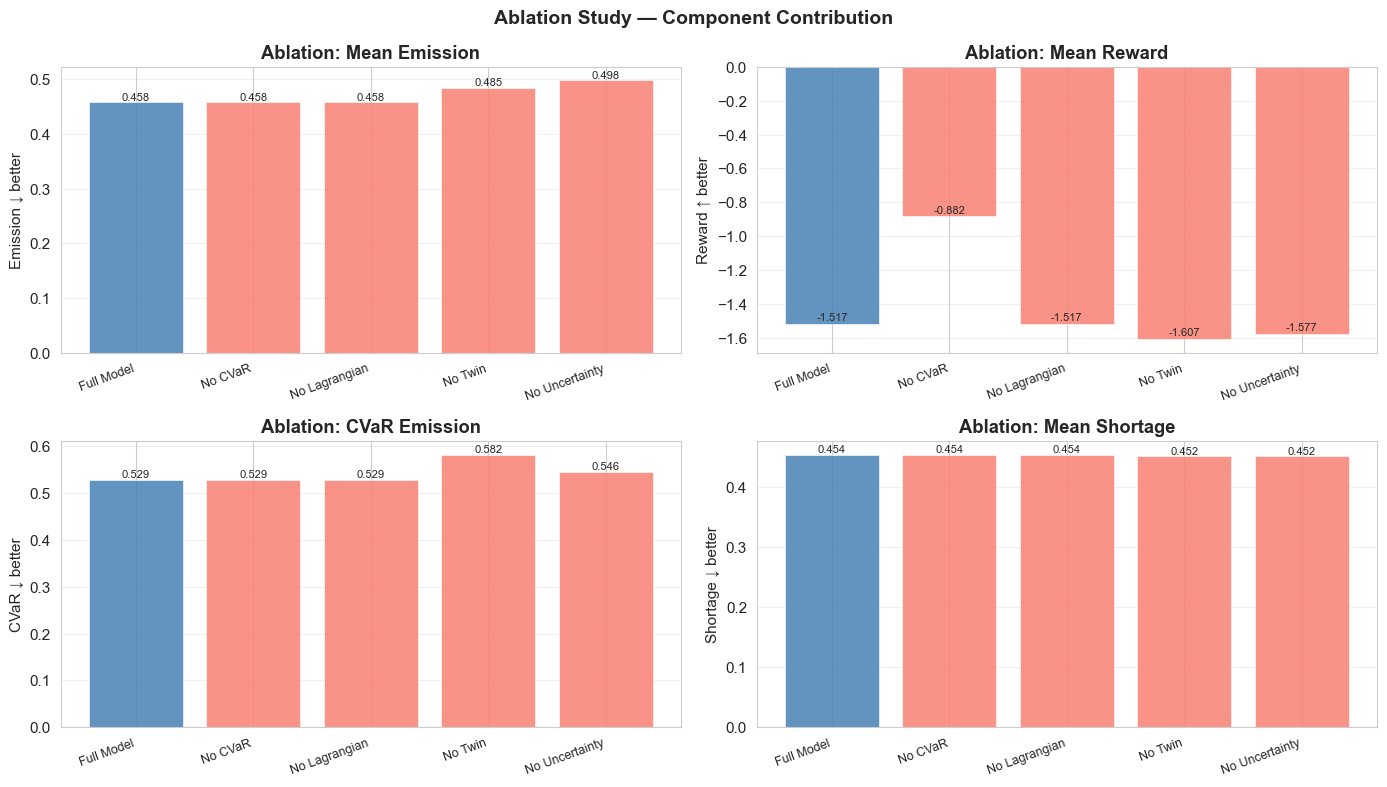

💾 Saved: 06_ablation_study.png


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [ ]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$

# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

# Risk-Constrained Carbon-Aware Reinforcement Learning for Power Grid Dispatch
## A Digital Twin Study of India — A* Complete Research Notebook

**Version:** 2.0 (Full Scientific Upgrade)  
**Dataset:** 4,588 rows, 26 features, 13 Indian states (2017–2024)  

---

### ✅ What This Notebook Implements (All 5 Missing Components Added)

| Component | v1 Status | v2 Status |
|-----------|-----------|----------|
| Data Pipeline | ✅ Good | ✅ Enhanced |
| **Carbon Digital Twin (LSTM)** | ❌ Missing | ✅ Implemented |
| **Probabilistic Forecasting (Quantile)** | ❌ Missing | ✅ Implemented |
| **Lagrangian Constrained PPO** | ❌ Missing | ✅ Implemented |
| **Multi-Source Dispatch Action Space** | ❌ Missing | ✅ Implemented |
| **Market Pricing Layer** | ❌ Missing | ✅ Implemented |
| CVaR Risk Penalty | 🟡 Basic | ✅ Enhanced |
| Dual Temporal Validation | ✅ Good | ✅ Enhanced |
| Ablation Study | ❌ Missing | ✅ Implemented |

---

### 📁 Required Folder Structure
```
final_RL_V2/
├── data/
│   ├── RL_TRAIN_DATA.csv          ← your train data
│   └── RL_TEST_DATA.csv           ← your test data
├── notebooks/
│   └── carbon_aware_rl_astar_complete.ipynb  ← THIS FILE
├── src/
│   ├── carbon_twin.py             ← auto-generated
│   ├── quantile_forecaster.py     ← auto-generated
│   ├── constrained_ppo.py         ← auto-generated
│   ├── grid_env.py                ← auto-generated
│   └── market_layer.py            ← auto-generated
└── results/
    ├── models/
    ├── logs/
    └── figures/
```

## 0. Install & Import Dependencies

In [ ]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [ ]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 2.0,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [ ]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """x: (B, T, F)"""
        out, _ = self.lstm(x)        # (B, T, H)
        last   = out[:, -1, :]       # (B, H)
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


In [ ]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [ ]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)

        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662



📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


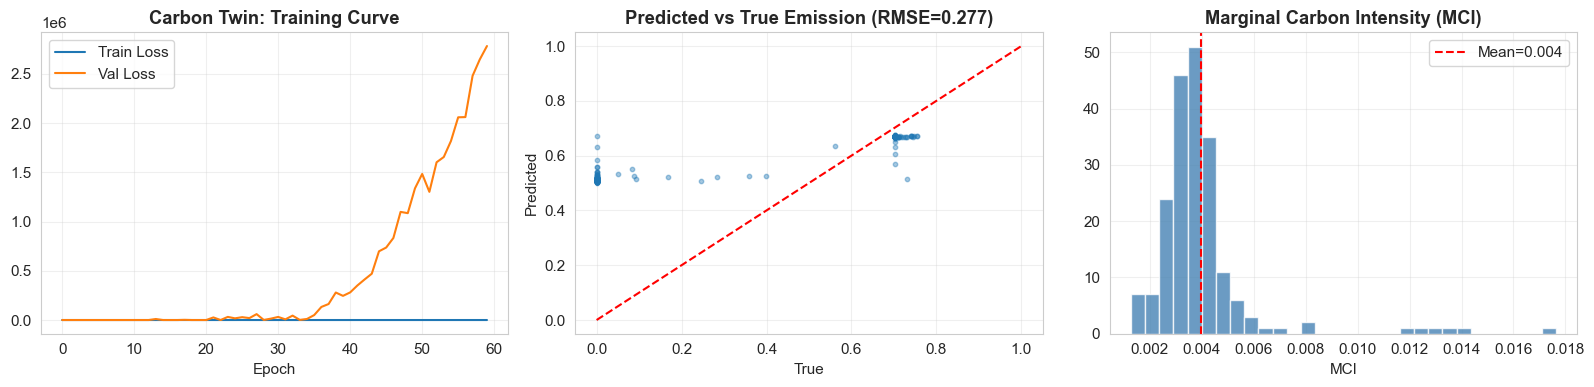

💾 Saved: 01_carbon_twin.png


In [ ]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [ ]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

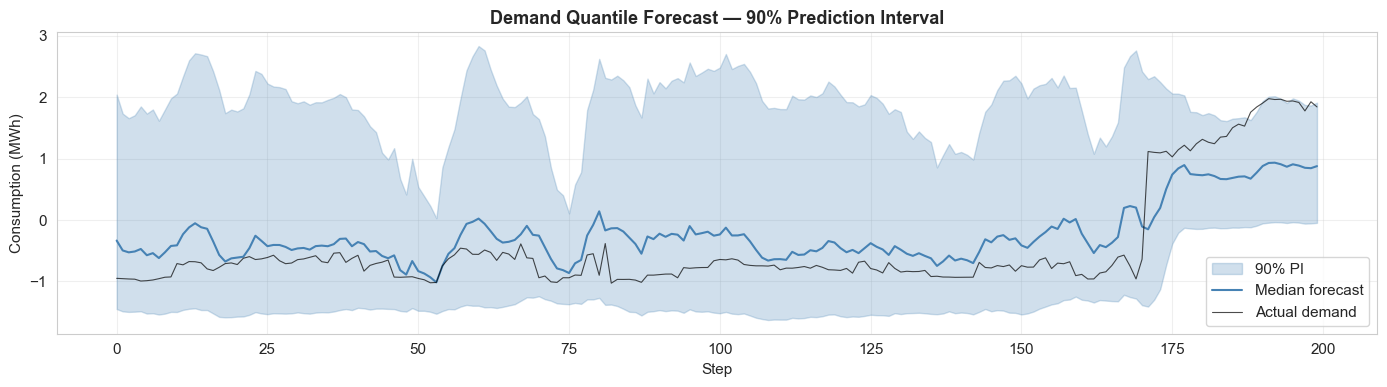

💾 Saved: 02_quantile_forecast.png


In [ ]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [ ]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [ ]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [ ]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [ ]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

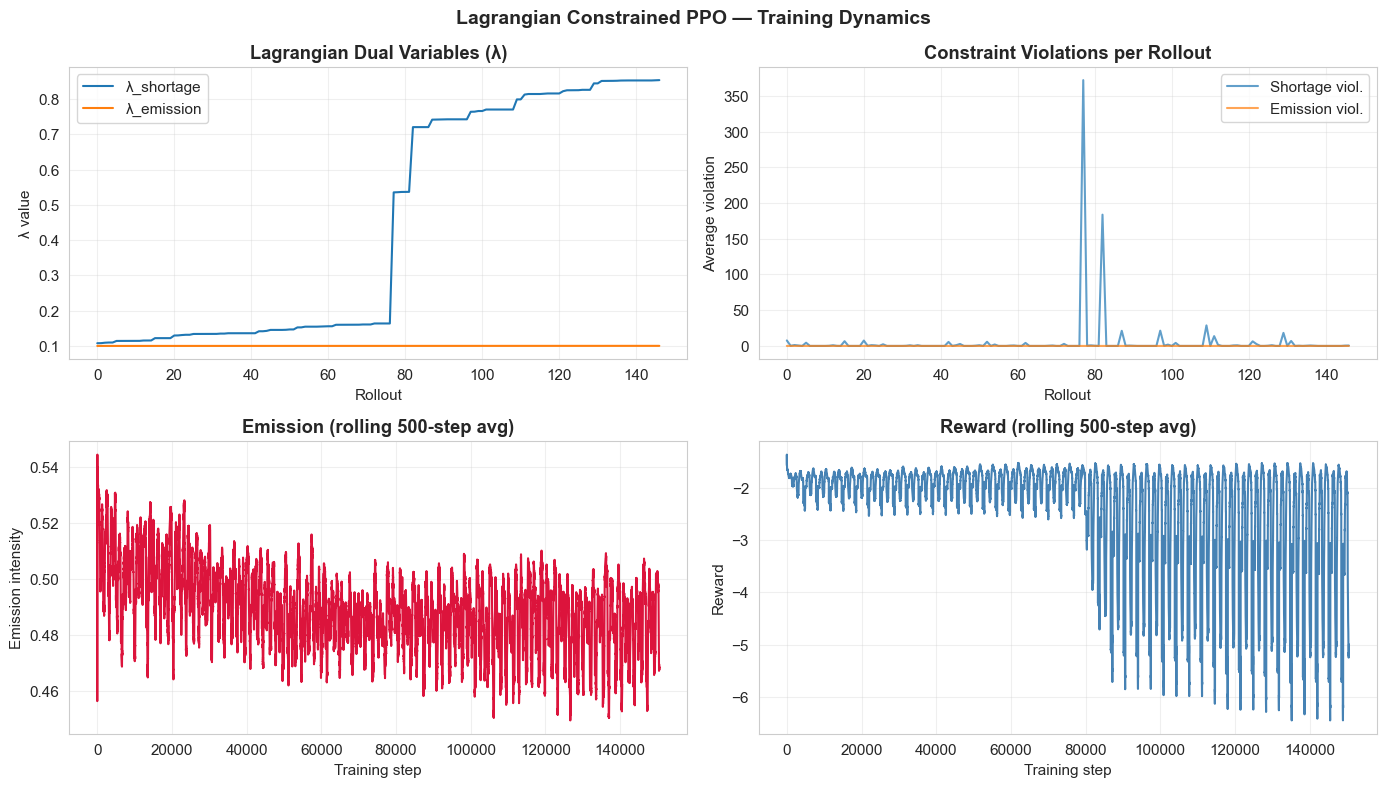

💾 Saved: 03_lagrangian_training.png


In [ ]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            # g['score'] = g['emission'] * 10000   # scale
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * g['base_bid']
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [ ]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


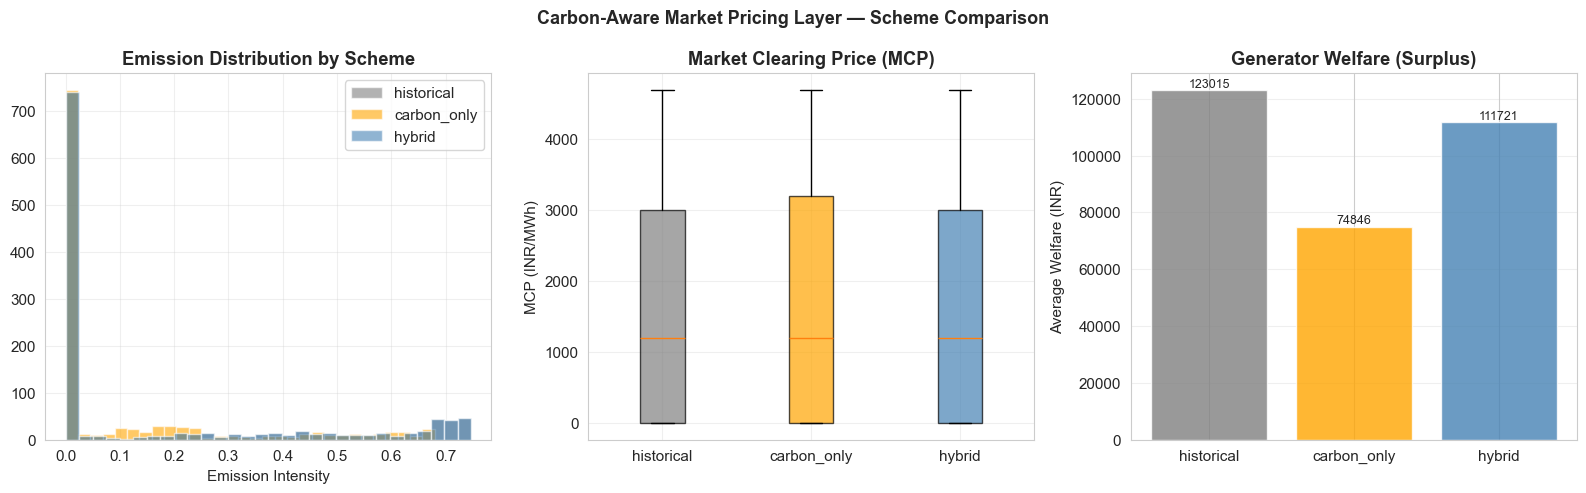

💾 Saved: 04_market_pricing.png


In [ ]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [ ]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [ ]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [ ]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


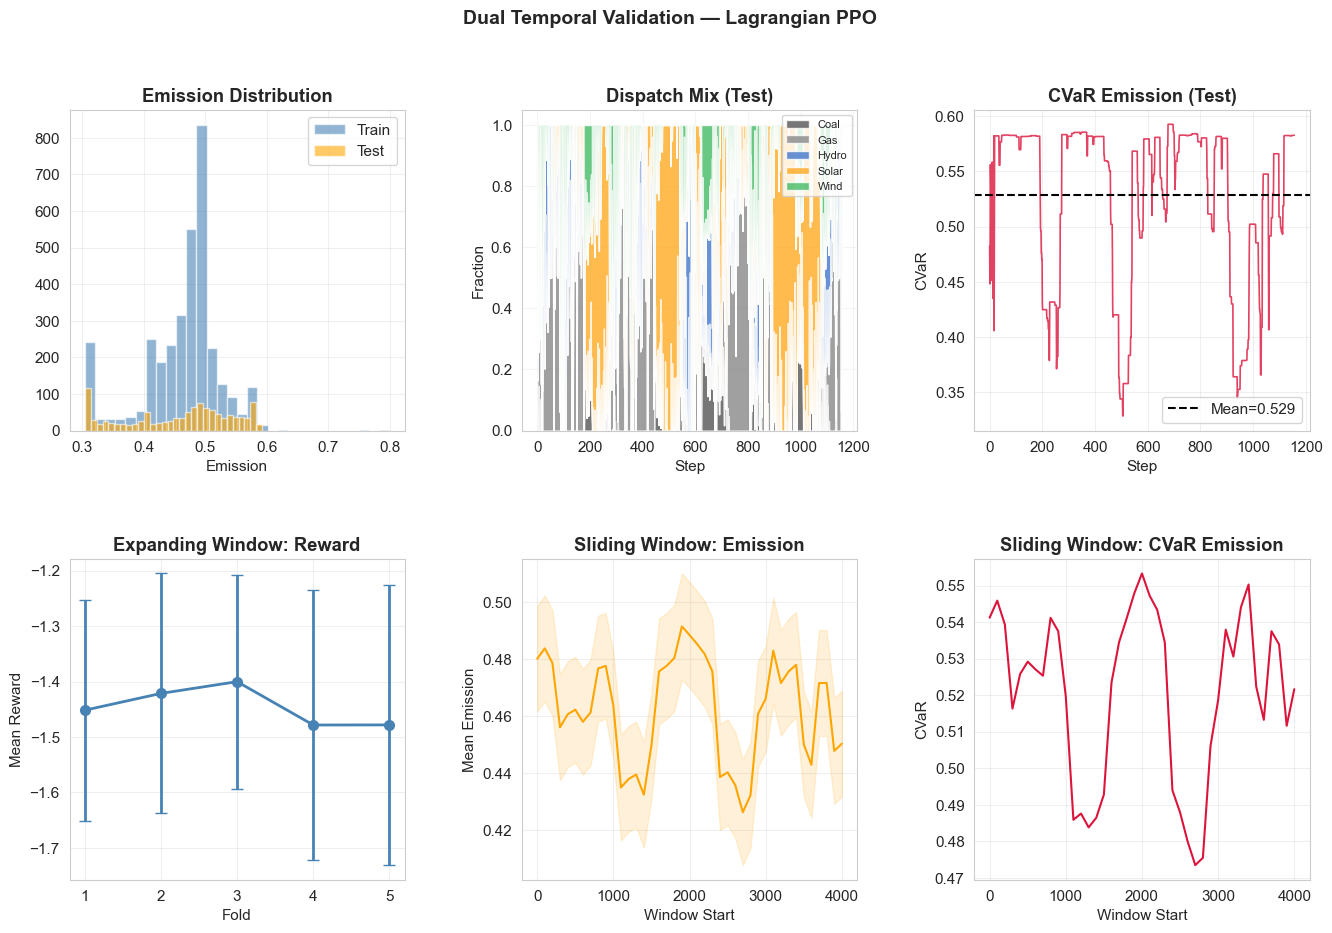

💾 Saved: 05_dual_temporal_validation.png


In [ ]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

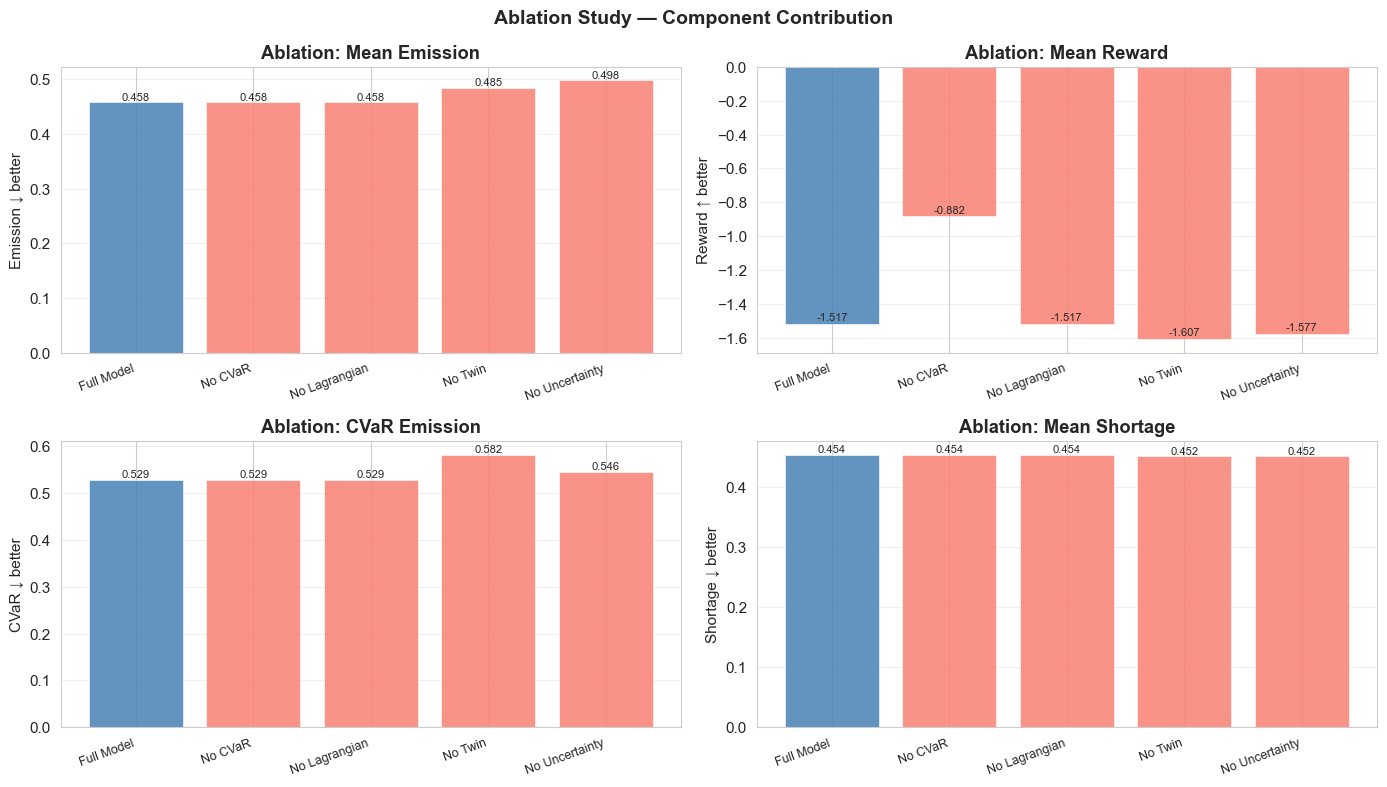

💾 Saved: 06_ablation_study.png


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [ ]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$

## 0. Install & Import Dependencies

In [ ]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [ ]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 1.2,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [ ]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """x: (B, T, F)"""
        out, _ = self.lstm(x)        # (B, T, H)
        last   = out[:, -1, :]       # (B, H)
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


In [ ]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [ ]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)
        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662



📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


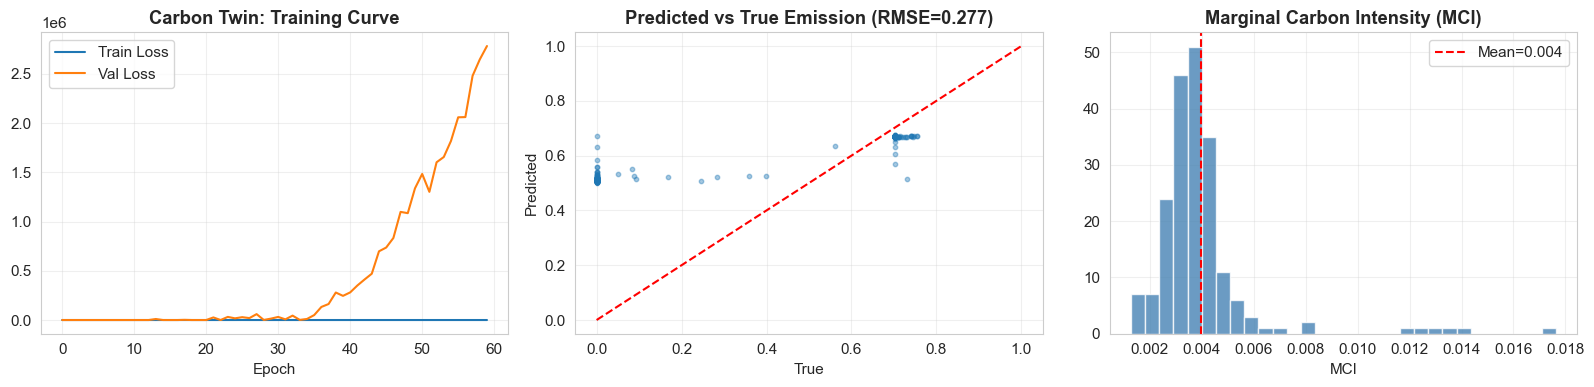

💾 Saved: 01_carbon_twin.png


In [ ]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [ ]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

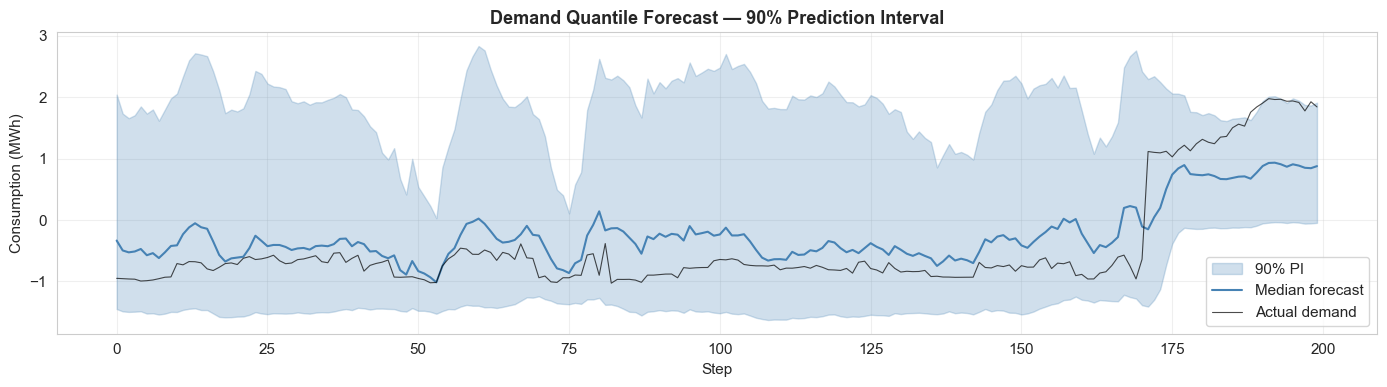

💾 Saved: 02_quantile_forecast.png


In [ ]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [ ]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [ ]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [ ]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [ ]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

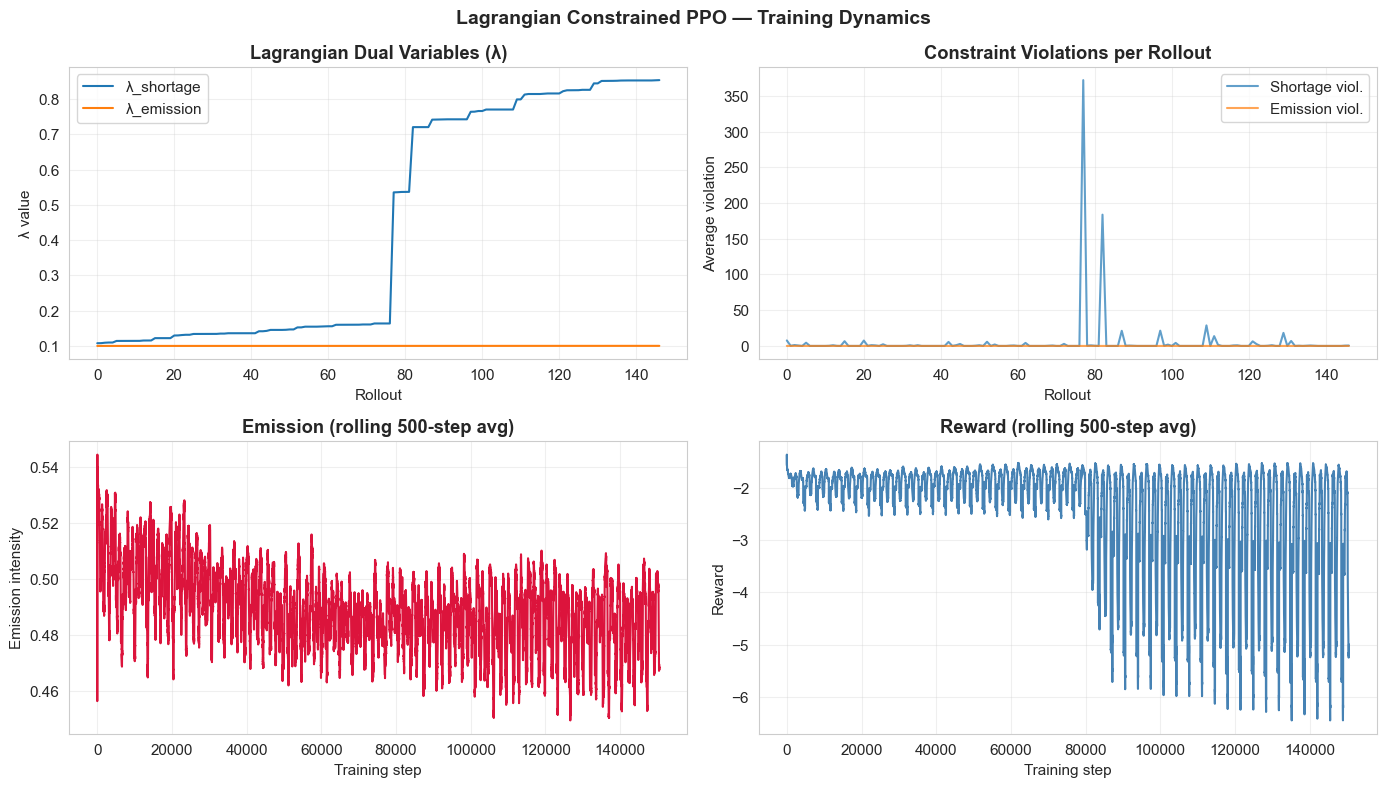

💾 Saved: 03_lagrangian_training.png


In [ ]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            g['score'] = g['emission'] * 10000   # scale
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [ ]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


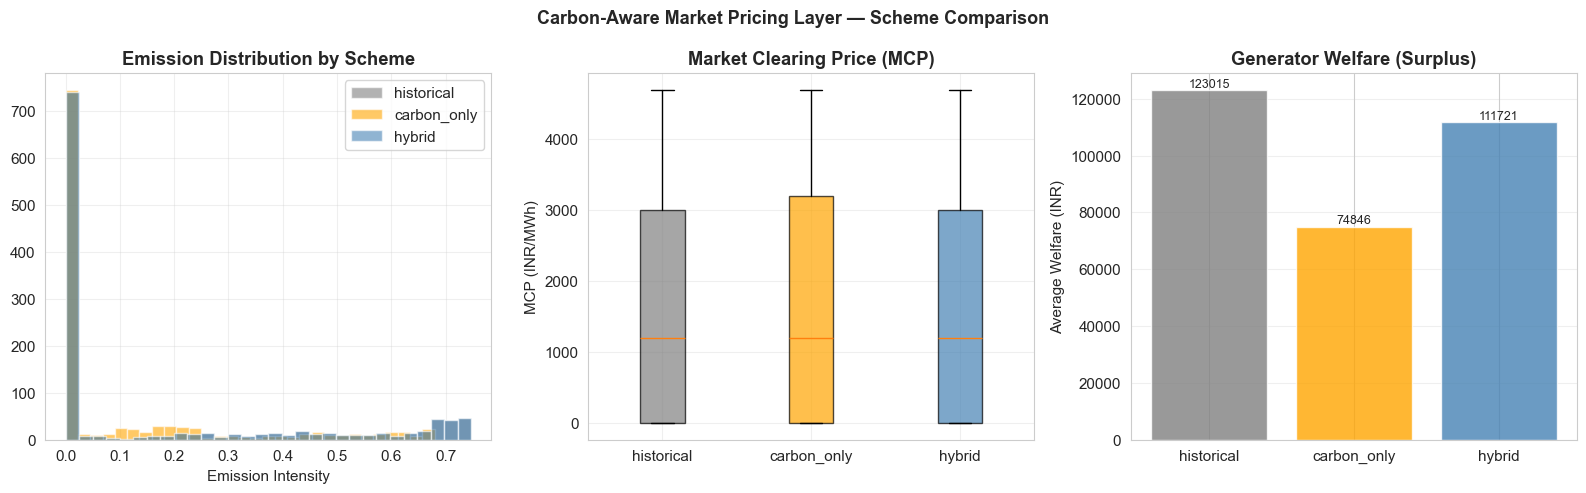

💾 Saved: 04_market_pricing.png


In [ ]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [ ]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [ ]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [ ]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


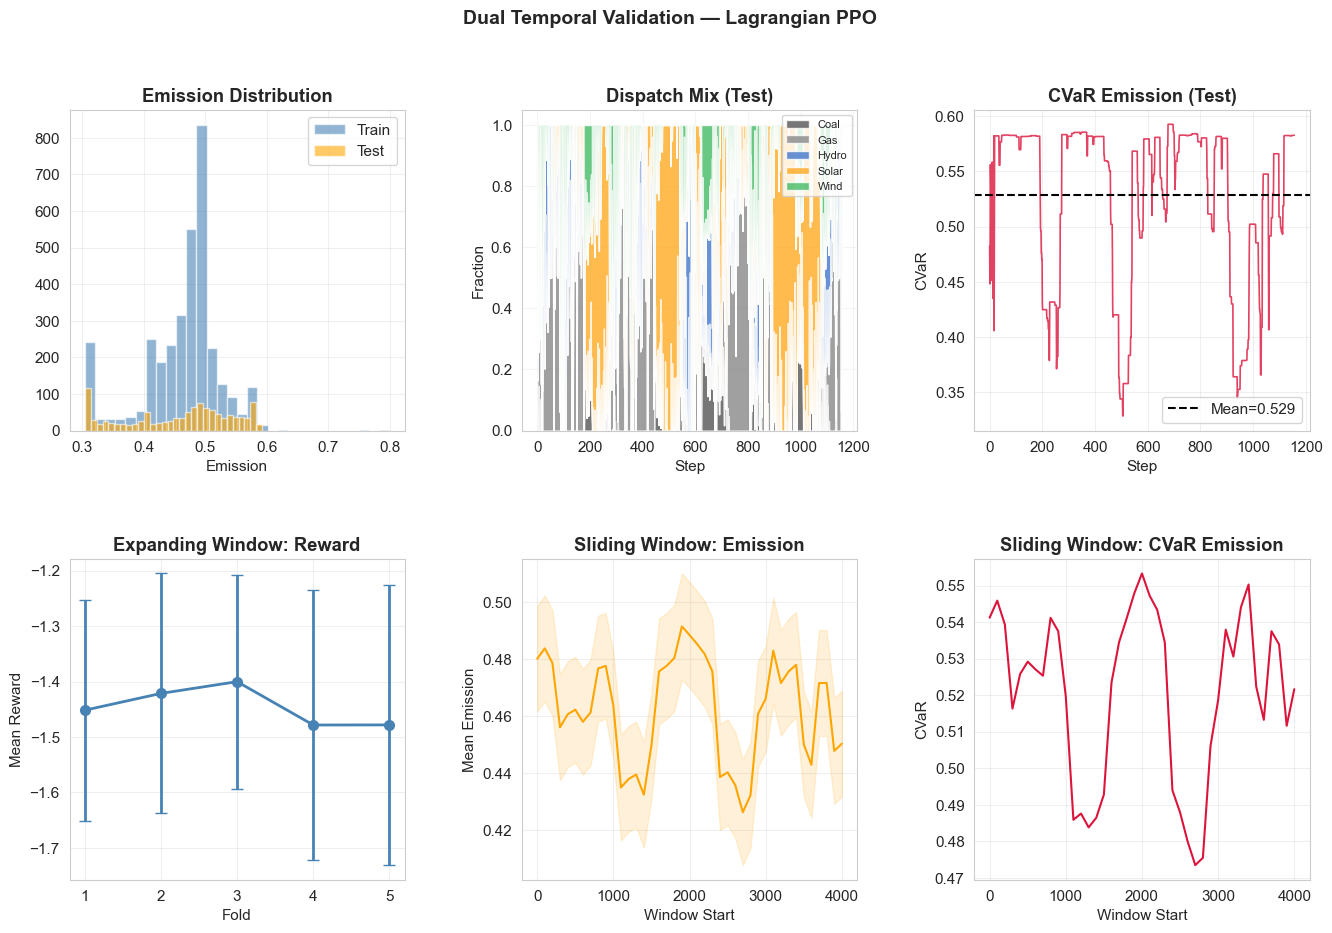

💾 Saved: 05_dual_temporal_validation.png


In [ ]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

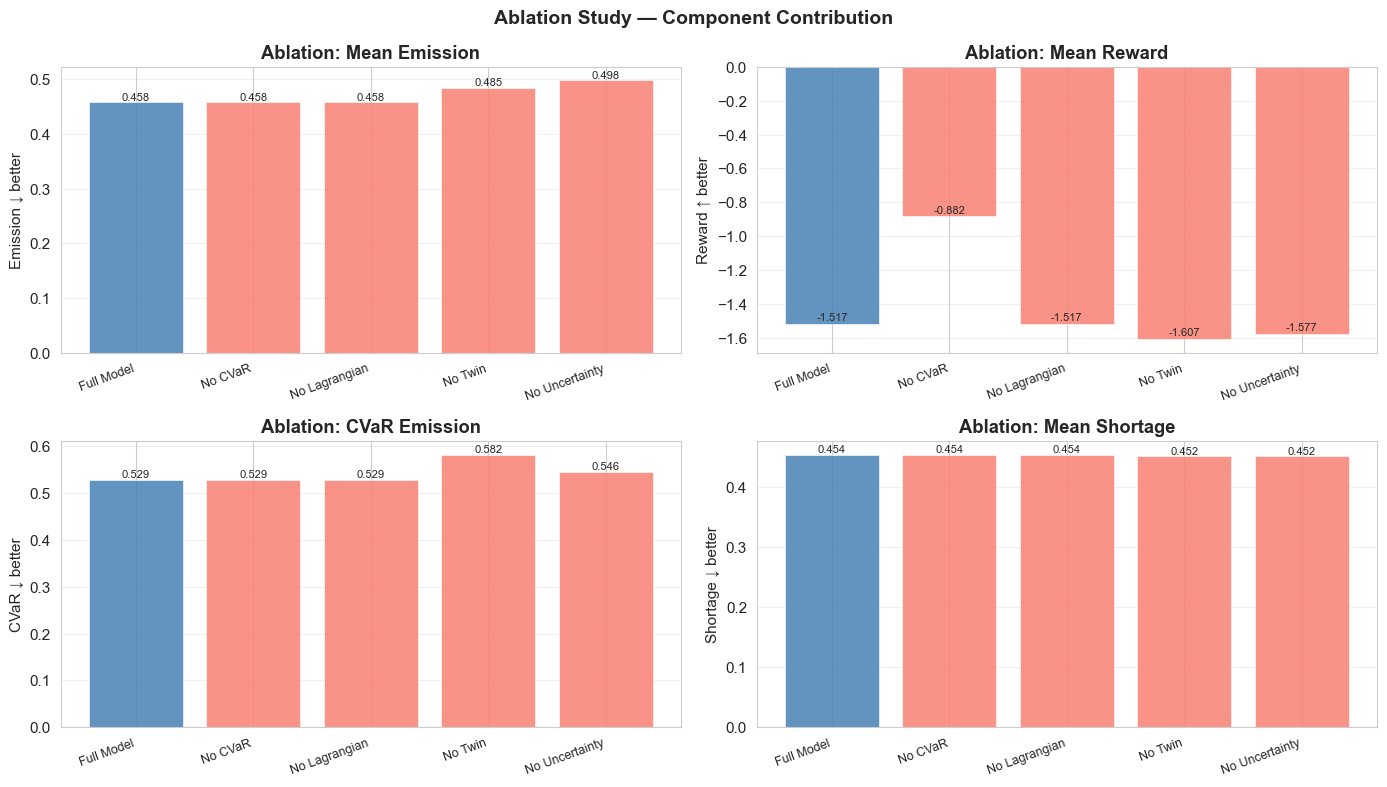

💾 Saved: 06_ablation_study.png


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [ ]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$

## 0. Install & Import Dependencies

In [ ]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [ ]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 1.2,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [ ]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """x: (B, T, F)"""
        out, _ = self.lstm(x)        # (B, T, H)
        last   = out[:, -1, :]       # (B, H)
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


In [ ]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [ ]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)
        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662



📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


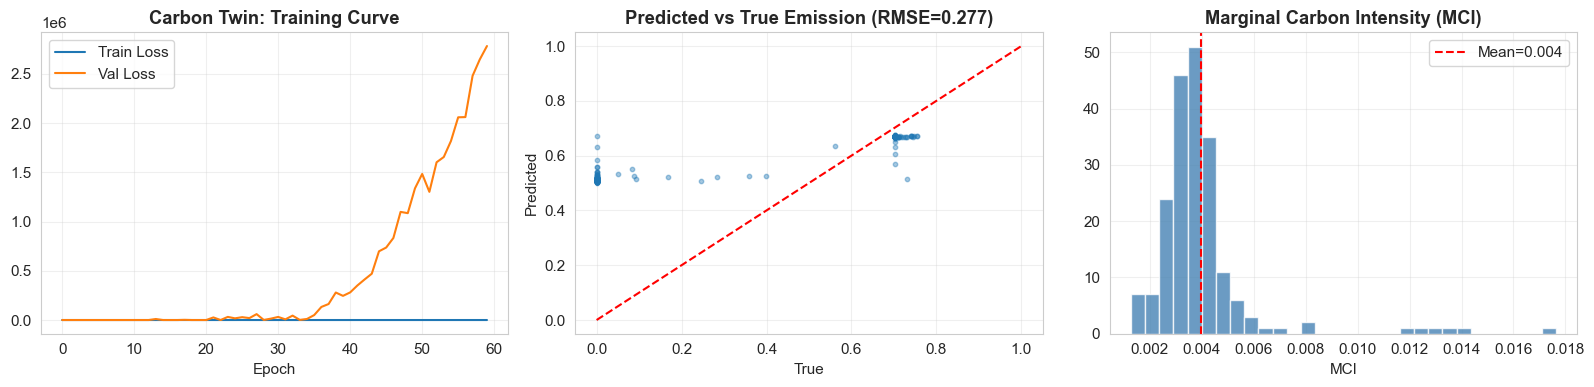

💾 Saved: 01_carbon_twin.png


In [ ]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [ ]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

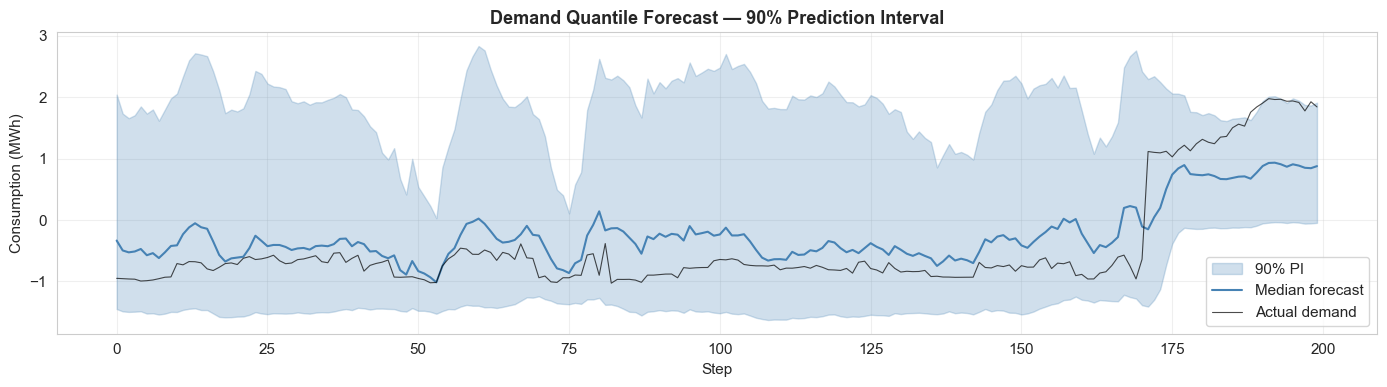

💾 Saved: 02_quantile_forecast.png


In [ ]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [ ]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [ ]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [ ]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [ ]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

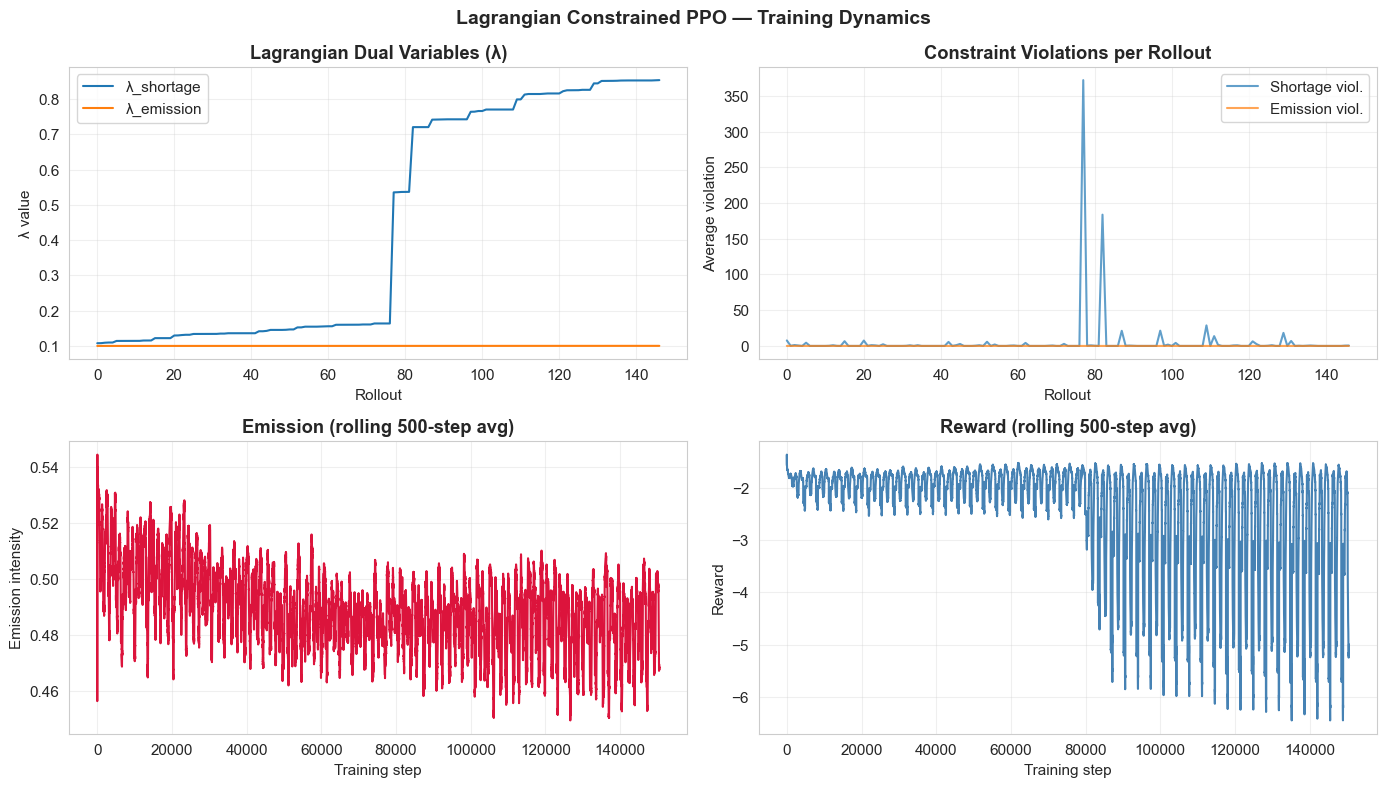

💾 Saved: 03_lagrangian_training.png


In [ ]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            g['score'] = g['emission'] * 10000   # scale
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [ ]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


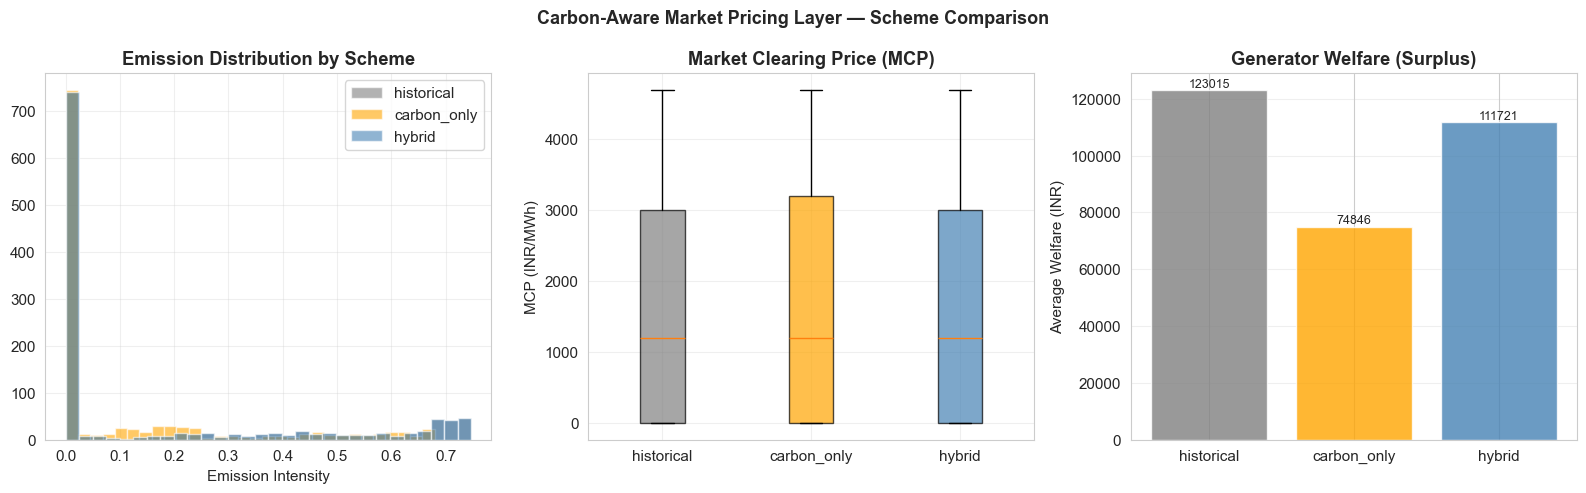

💾 Saved: 04_market_pricing.png


In [ ]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [ ]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [ ]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [ ]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


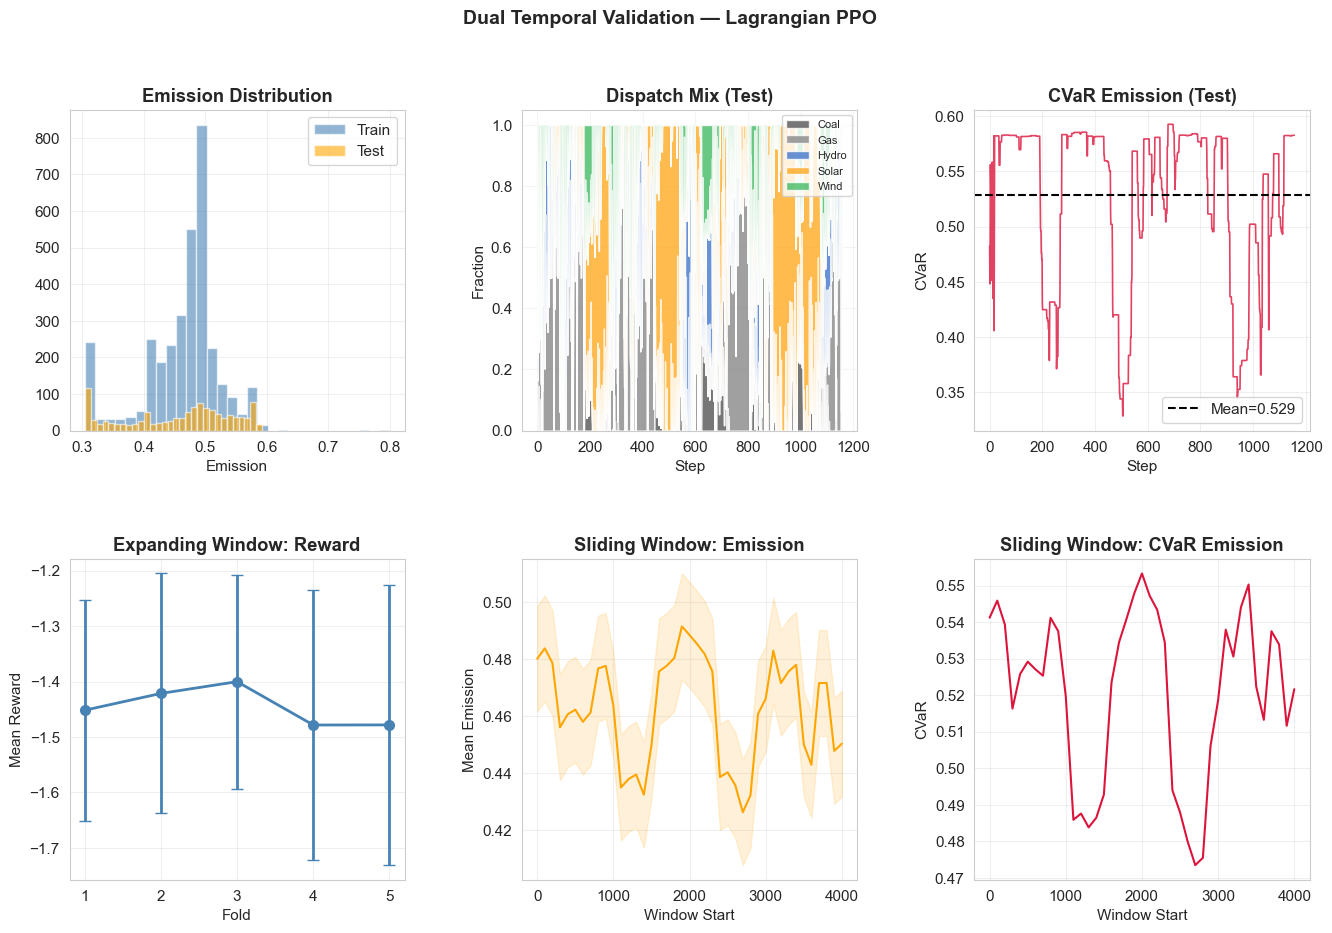

💾 Saved: 05_dual_temporal_validation.png


In [ ]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

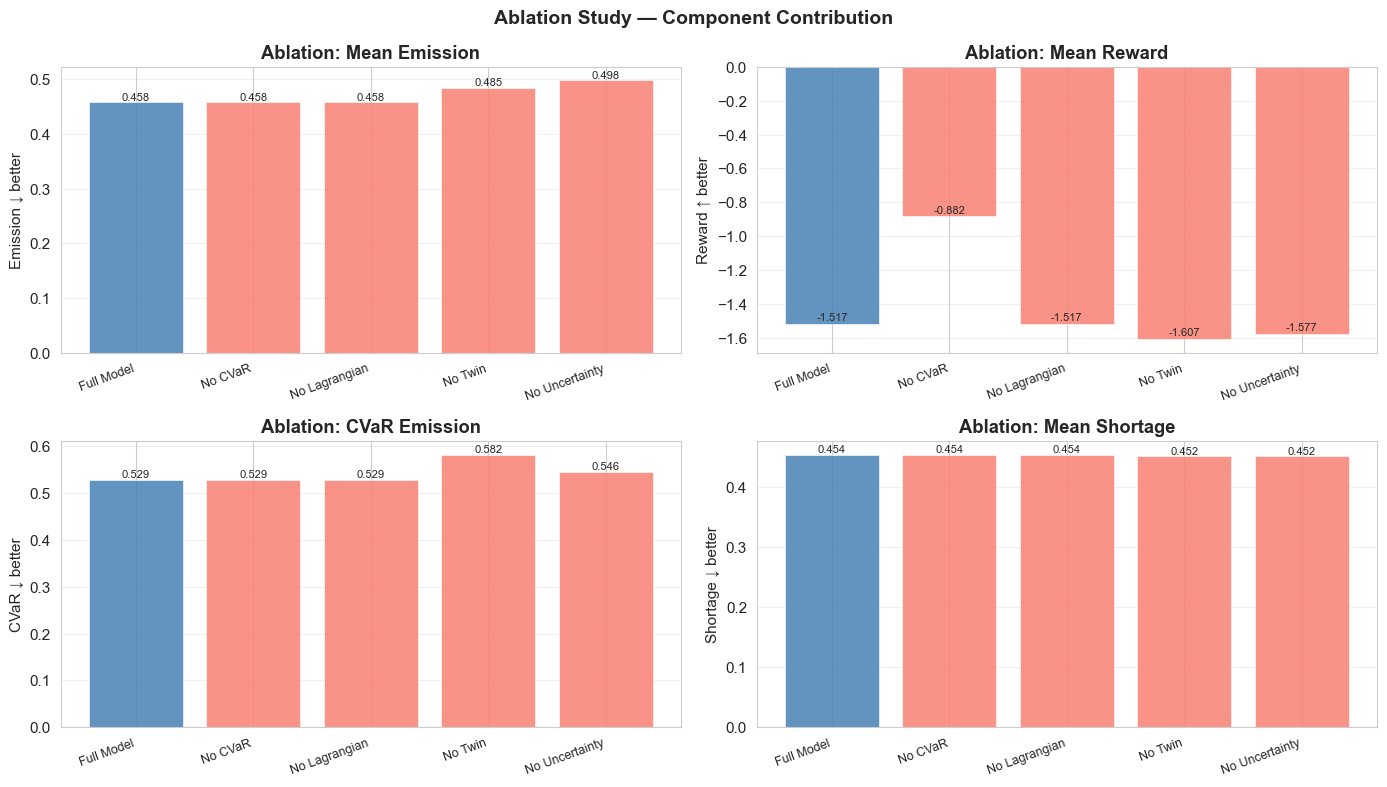

💾 Saved: 06_ablation_study.png


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [ ]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$

## 0. Install & Import Dependencies

In [ ]:
# Run this cell ONCE to install all dependencies
# !pip install gymnasium==0.29.1 stable-baselines3==2.2.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy joblib tqdm
print("If packages are missing, uncomment the lines above and run them first.")

If packages are missing, uncomment the lines above and run them first.


In [ ]:
import os, sys, json, warnings, time
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import joblib

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, BaseCallback
from stable_baselines3.common.utils import obs_as_tensor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ All libraries loaded
🖥️  Device: cuda
🔥 PyTorch: 2.5.1+cu118


## 1. Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath('..')
DATA_DIR     = os.path.join(BASE_DIR, 'data')
SRC_DIR      = os.path.join(BASE_DIR, 'src')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(RESULTS_DIR, 'models')
LOGS_DIR     = os.path.join(RESULTS_DIR, 'logs')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')

for d in [SRC_DIR, MODELS_DIR, LOGS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Base: {BASE_DIR}")
print(f"📊 Data: {DATA_DIR}")

# ── Master Config ──────────────────────────────────────────────────────
CONFIG = {

    # ── Reproducibility ──
    'seed': 42,

    # ── Carbon Digital Twin ──
    'twin_seq_len': 14,
    'twin_hidden': 128,
    'twin_layers': 2,
    'twin_epochs': 60,
    'twin_lr': 1e-3,
    'twin_batch': 64,

    # ── Quantile Forecaster ──
    'qf_seq_len': 7,
    'qf_hidden': 64,
    'qf_epochs': 50,
    'qf_lr': 1e-3,
    'qf_batch': 64,
    'quantiles': [0.05, 0.5, 0.95],

    # ── RL / PPO ──
    'total_timesteps': 150_000,
    'n_steps': 1024,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,

    # ── Reward weights ──
    'w_emission': 1.0,
    'w_outage': 2.0,
    'w_gap': 0.5,
    'w_cvar': 1.2,
    'w_price': 0.2,

    # ── Lagrangian Constraint ──
    'lambda_init': 0.1,
    'lambda_lr': 0.001,
    'shortage_budget': 0.02,
    'emission_budget': 0.7,

    # ── CVaR ──
    'cvar_alpha': 0.95,
    'cvar_window': 20,

    # ── Evaluation ──
    'eval_freq': 10_000,
    'n_eval_episodes': 3,
    'checkpoint_freq': 20_000,
    'expanding_window_folds': 5,
    'sliding_window_size': 500,
    'sliding_window_stride': 100,

    # ── Market Layer ──
    'carbon_price_per_unit': 0.15,
    'carbon_rebate_delta': 0.05,
}

# ── Deterministic setup ───────────────────────────────────────────────
import random

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("⚙️  Config loaded — deterministic execution enabled.")

📁 Base: c:\Users\Ohi\Desktop\m\final_RL_V2
📊 Data: c:\Users\Ohi\Desktop\m\final_RL_V2\data
⚙️  Config loaded — deterministic execution enabled.


## 2. Data Loading & Feature Engineering

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'RL_TRAIN_DATA.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'RL_TEST_DATA.csv'))

def safe_col(df, col, fallback=0.0):
    if col not in df.columns:
        df[col] = fallback

for df in [train_df, test_df]:
    safe_col(df, 'outage_ratio')
    # ── Construct emission proxy from generation mix ──────────────────
    # coal-heavy generation = high emission; renewables = low emission
    # Formula: emission_intensity = (1 - renewable_ratio) * (1 + log_outage_factor)
    # This is the TARGET for the Carbon Digital Twin
    df['emission_intensity'] = (
        (1.0 - df['renewable_ratio'].clip(0, 1)) *
        (1.0 + 0.1 * df['log_outage_ratio'].clip(0))
    )
    # Coal dominance factor (proxy for MCI — marginal carbon intensity)
    df['coal_dominance'] = 1.0 - df['renewable_ratio'].clip(0, 1)
    # Capacity utilisation
    df['cap_util'] = (df['consumption_mwh'] / df['total_generation_mwh'].replace(0, np.nan)).fillna(0)
    # Season encoding (cyclical)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        doy = df['date'].dt.dayofyear.fillna(180)
        df['sin_doy'] = np.sin(2 * np.pi * doy / 365)
        df['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    else:
        df['sin_doy'] = 0.0
        df['cos_doy'] = 1.0

print(f"📊 Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"📋 Features available: {train_df.shape[1]} columns")
print("\n✅ Emission intensity column created (Digital Twin target)")
print(f"   emission_intensity stats: {train_df['emission_intensity'].describe().to_dict()}")

📊 Train: 3431 rows  |  Test: 1157 rows
📋 Features available: 24 columns

✅ Emission intensity column created (Digital Twin target)
   emission_intensity stats: {'count': 3431.0, 'mean': 0.8861620910587862, 'std': 0.336188265796394, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 1.023787470246556, 'max': 1.423132408543206}


In [ ]:
# Feature sets used across the pipeline

EXCLUDE = ['date', 'state_name', 'state_id']

# ── Carbon Digital Twin ──────────────────────────────────────
TWIN_FEATURES = [
    'total_generation_mwh',
    'renewable_ratio',
    'coal_dominance',
    'cap_util',
    'avg_coal_stock_days',
    'outage_ratio',
    'consumption_mwh',
    'price_momentum_7',
    'demand_growth',
    'post_2021_regime',
    'sin_doy',
    'cos_doy'
]

TWIN_TARGET = 'emission_intensity'


# ── Quantile Forecasters (SEPARATED TO AVOID LEAKAGE) ───────

# Demand forecaster inputs (exclude consumption_mwh!)
QF_INPUT_DEMAND = [
    'log_price',
    'renewable_ratio',
    'avg_coal_stock_days',
    'outage_ratio',
    'demand_growth',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_DEMAND = 'consumption_mwh'


# Renewable forecaster inputs (exclude renewable_ratio!)
QF_INPUT_RENEW = [
    'log_price',
    'consumption_mwh',
    'avg_coal_stock_days',
    'outage_ratio',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

QF_TARGET_RENEW = 'renewable_ratio'


# ── RL State Base Features ───────────────────────────────────
# (Only columns that ACTUALLY exist in your dataset)

RL_BASE_FEATURES = [
    'renewable_ratio',
    'outage_ratio',
    'supply_demand_gap',
    'avg_coal_stock_days',
    'consumption_mwh',
    'log_price',
    'log_outage_ratio',
    'demand_growth',
    'price_momentum_7',
    'coal_dominance',
    'cap_util',
    'sin_doy',
    'cos_doy',
    'post_2021_regime'
]

print("✅ Feature sets defined:")
print(f"   Twin inputs: {len(TWIN_FEATURES)}")
print(f"   QF demand inputs: {len(QF_INPUT_DEMAND)}")
print(f"   QF renew inputs: {len(QF_INPUT_RENEW)}")
print(f"   RL base features: {len(RL_BASE_FEATURES)}")

✅ Feature sets defined:
   Twin inputs: 12
   QF demand inputs: 8
   QF renew inputs: 7
   RL base features: 14


## 3. COMPONENT 1 — Carbon Digital Twin (LSTM)

We train an LSTM to learn the dynamic emission function:
$$E_t = f_\theta(G_t, D_t, CS_t, O_t, \text{season}, \text{history})$$
and derive the Marginal Carbon Intensity (MCI):
$$\text{MCI}_t = \frac{\partial E_t}{\partial G_{\text{coal},t}}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CARBON DIGITAL TWIN  —  LSTM-based emission learning
# ═══════════════════════════════════════════════════════════════════════

class CarbonDigitalTwin(nn.Module):
    """
    LSTM-based model that learns:
      E_t = f_θ(G_t, D_t, CS_t, O_t, season, history)
    
    Architecture:
      - LSTM encoder for temporal history
      - MLP head to predict emission intensity
      - Distributional output: mean + log-variance (aleatoric uncertainty)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # self.head_mean = nn.Sequential(
        #     nn.Linear(hidden, 64), nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(64, 1)
        # )
        self.head_mean = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_logvar = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """x: (B, T, F)"""
        out, _ = self.lstm(x)        # (B, T, H)
        last   = out[:, -1, :]       # (B, H)
        mean   = self.head_mean(last).squeeze(-1)    # (B,)
        logvar = self.head_logvar(last).squeeze(-1)  # (B,)
        return mean, logvar

    def predict_emission(self, x):
        """Inference: return mean emission."""
        self.eval()
        with torch.no_grad():
            mean, _ = self.forward(x)
        return torch.sigmoid(mean)   # clip to [0,1]


def build_sequences(df, feature_cols, target_col, seq_len, scaler_X=None, scaler_y=None):
    """Build (X, y) sequences for LSTM training."""
    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    if scaler_X is None:
        scaler_X = StandardScaler()
        X_raw = scaler_X.fit_transform(X_raw)
    else:
        X_raw = scaler_X.transform(X_raw)

    if scaler_y is None:
        scaler_y = MinMaxScaler()
        y_raw = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()
    else:
        y_raw = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])

    return (np.array(Xs), np.array(ys), scaler_X, scaler_y)


def heteroscedastic_loss(pred_mean, pred_logvar, target):
    """Gaussian NLL (heteroscedastic) loss."""
    precision = torch.exp(-pred_logvar)
    return torch.mean(precision * (target - pred_mean)**2 + pred_logvar)


print("✅ CarbonDigitalTwin class defined")

✅ CarbonDigitalTwin class defined


In [ ]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [ ]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)
        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662



📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


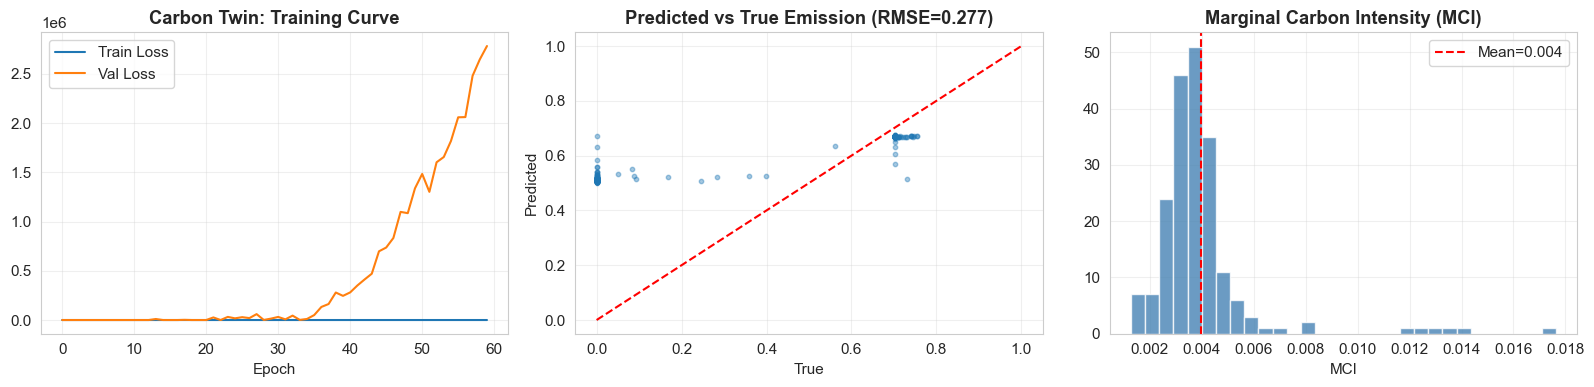

💾 Saved: 01_carbon_twin.png


In [ ]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [ ]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

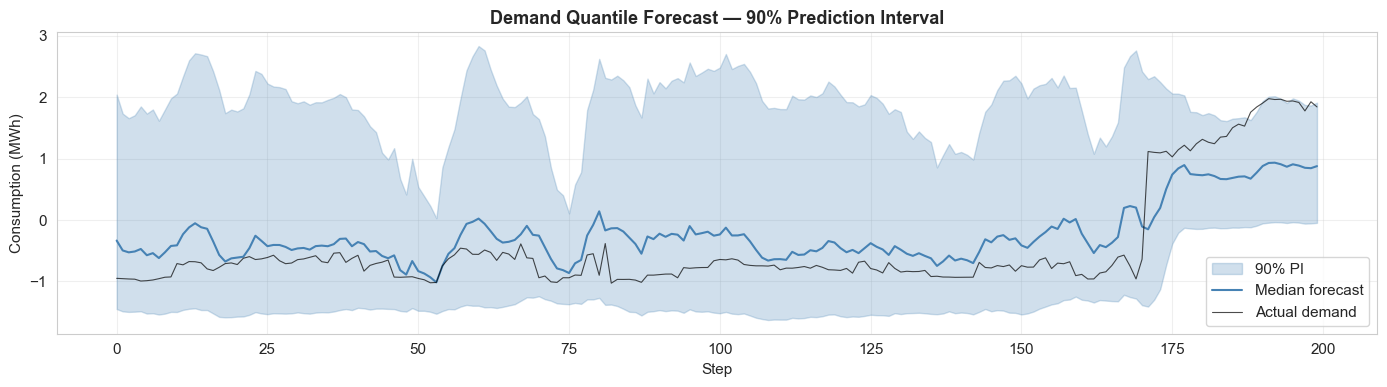

💾 Saved: 02_quantile_forecast.png


In [ ]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [ ]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [ ]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [ ]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [ ]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

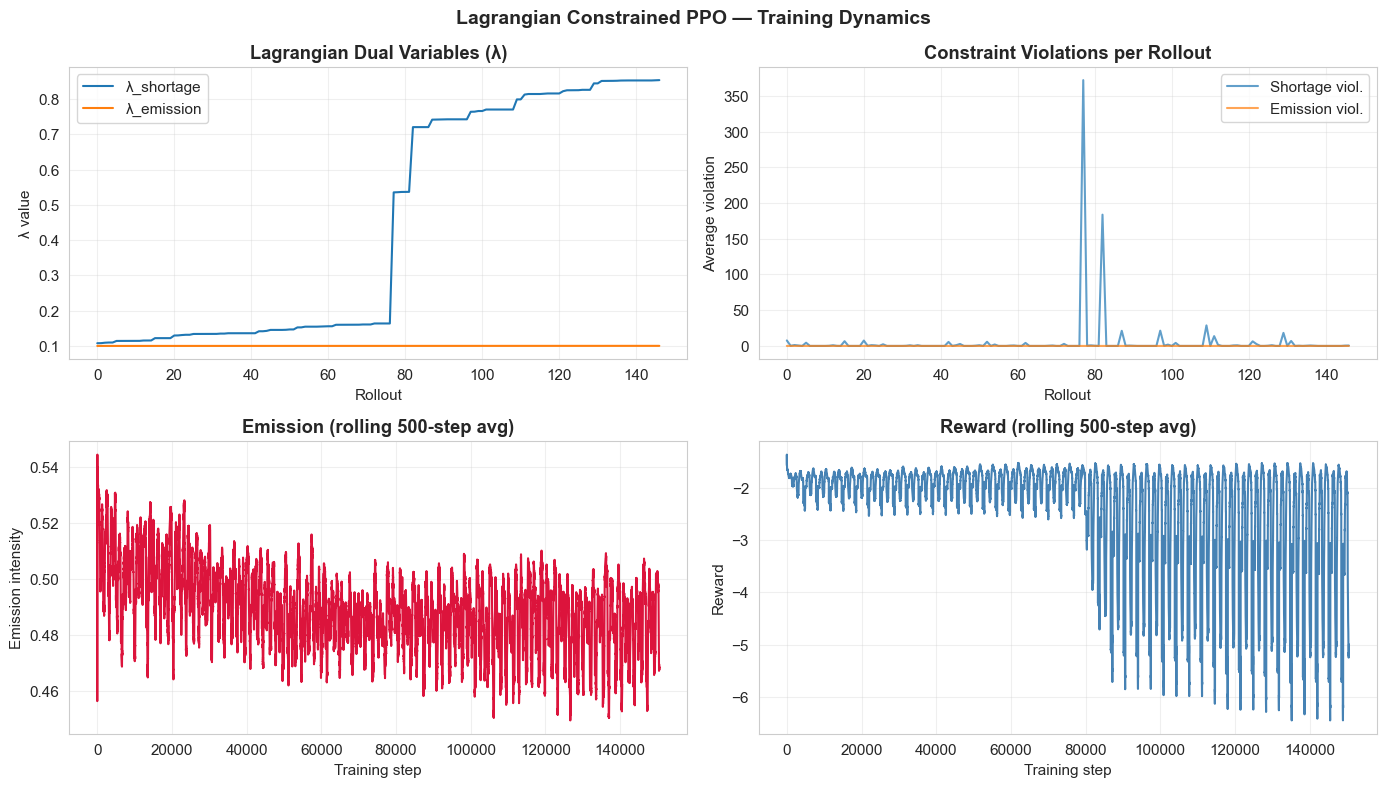

💾 Saved: 03_lagrangian_training.png


In [ ]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            g['score'] = g['emission'] * 10000   # scale
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [ ]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


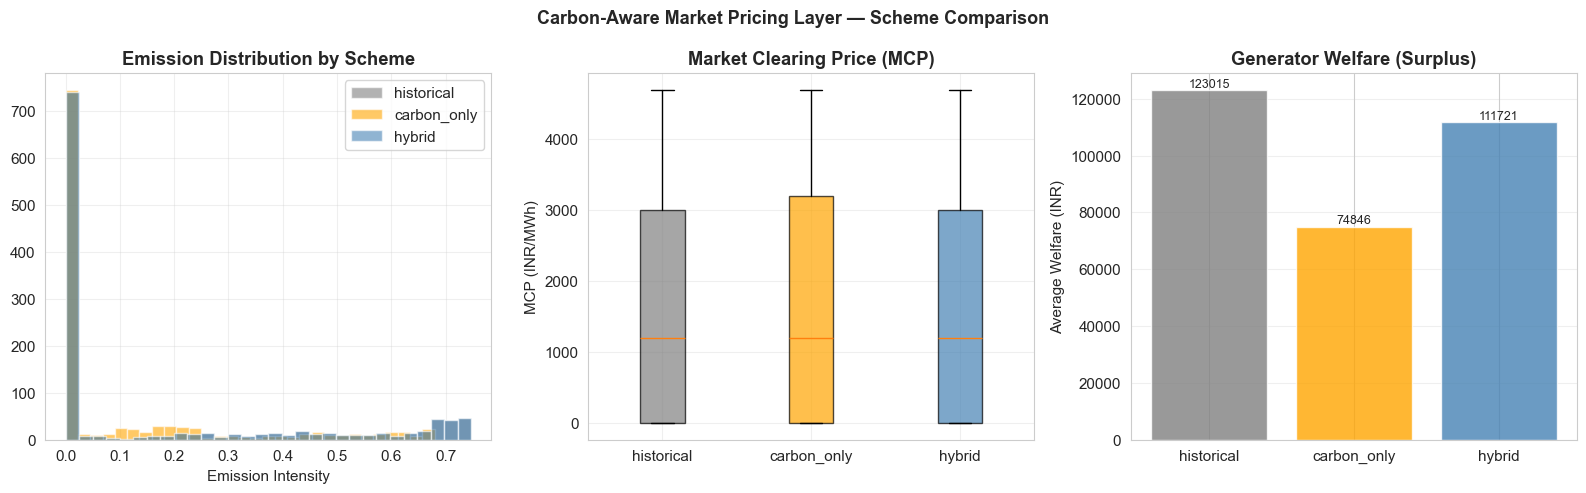

💾 Saved: 04_market_pricing.png


In [ ]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [ ]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [ ]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [ ]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


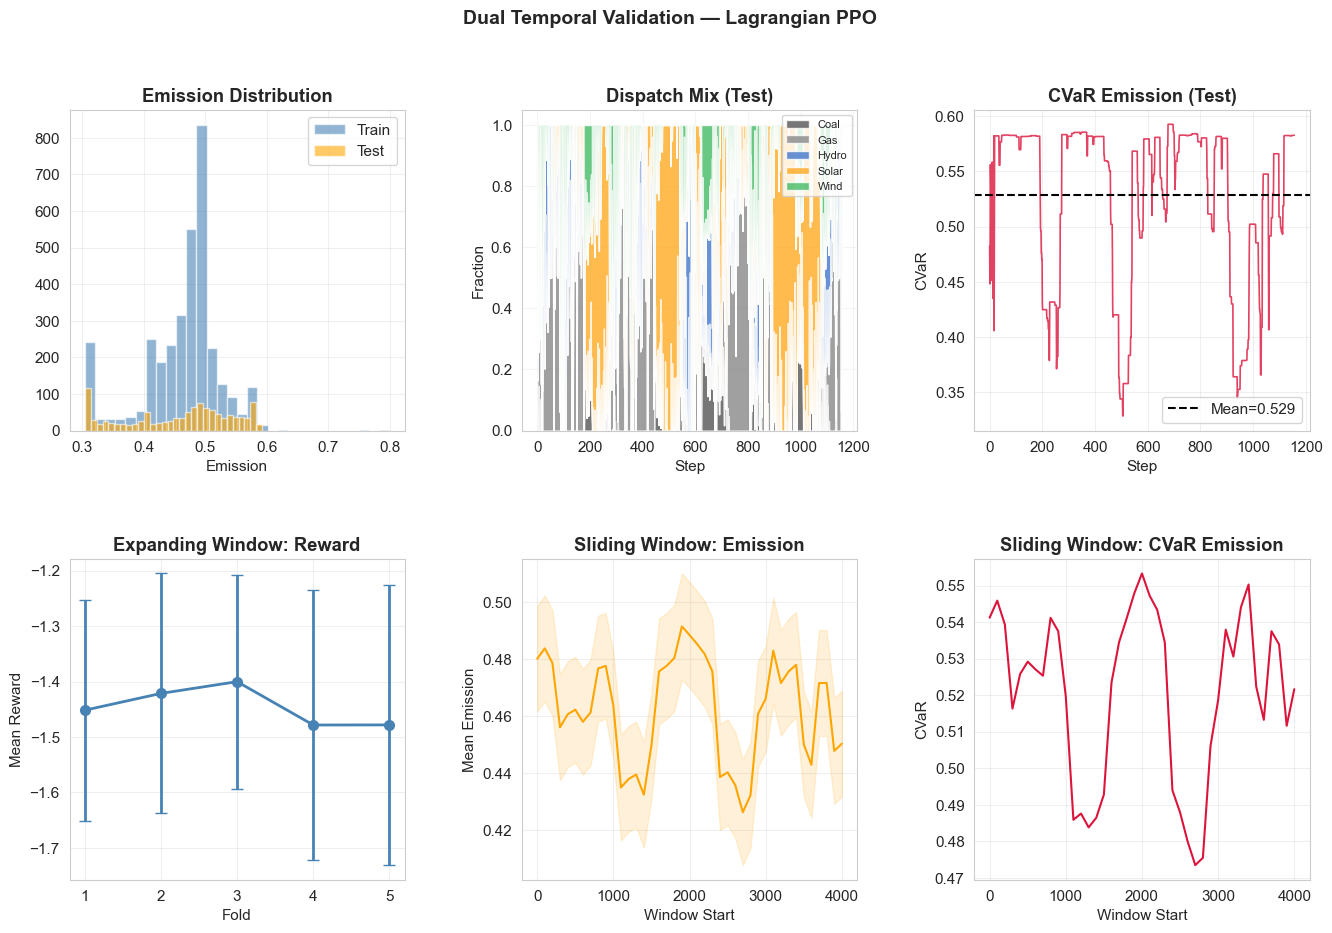

💾 Saved: 05_dual_temporal_validation.png


In [ ]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

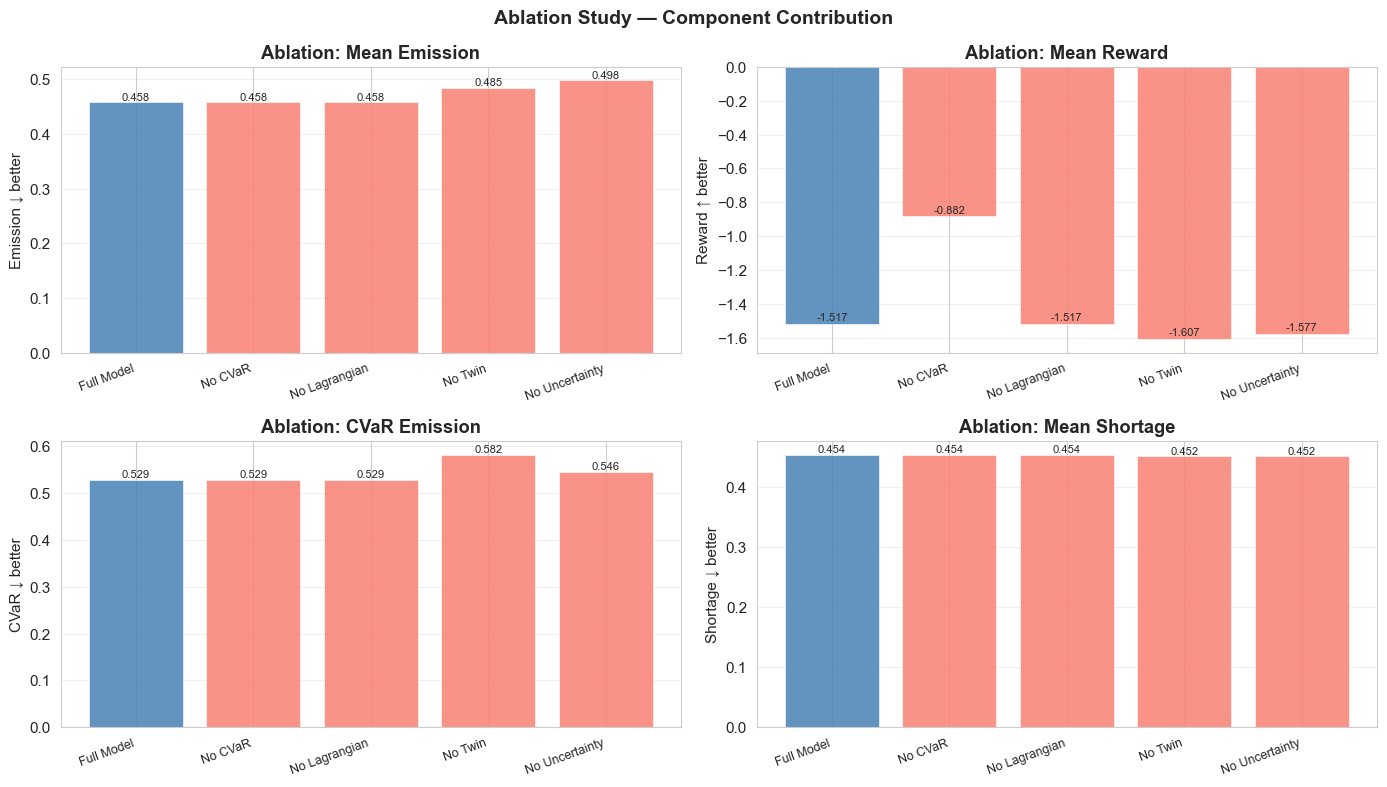

💾 Saved: 06_ablation_study.png


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [ ]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$


📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


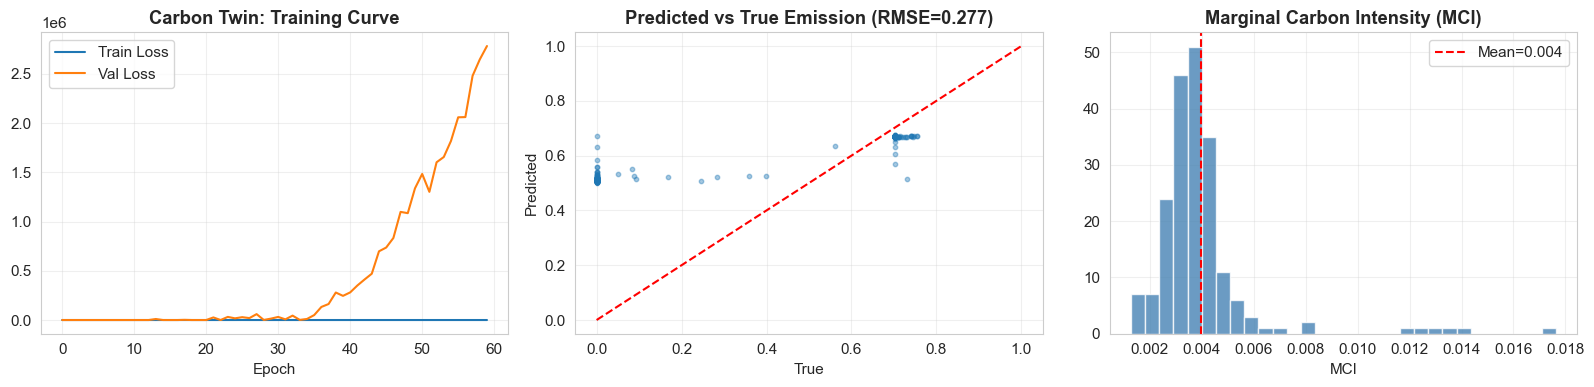

💾 Saved: 01_carbon_twin.png


In [ ]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [ ]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

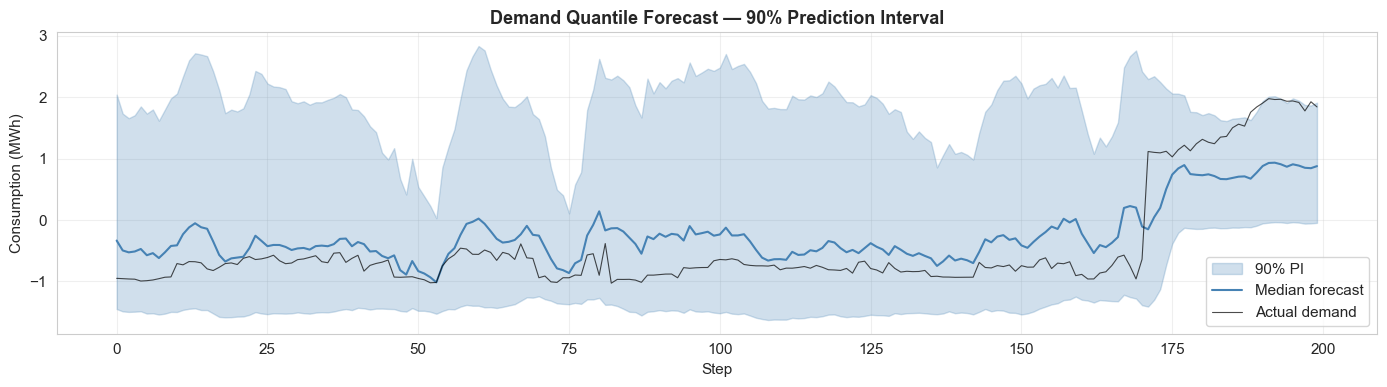

💾 Saved: 02_quantile_forecast.png


In [ ]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [ ]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [ ]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [ ]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [ ]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

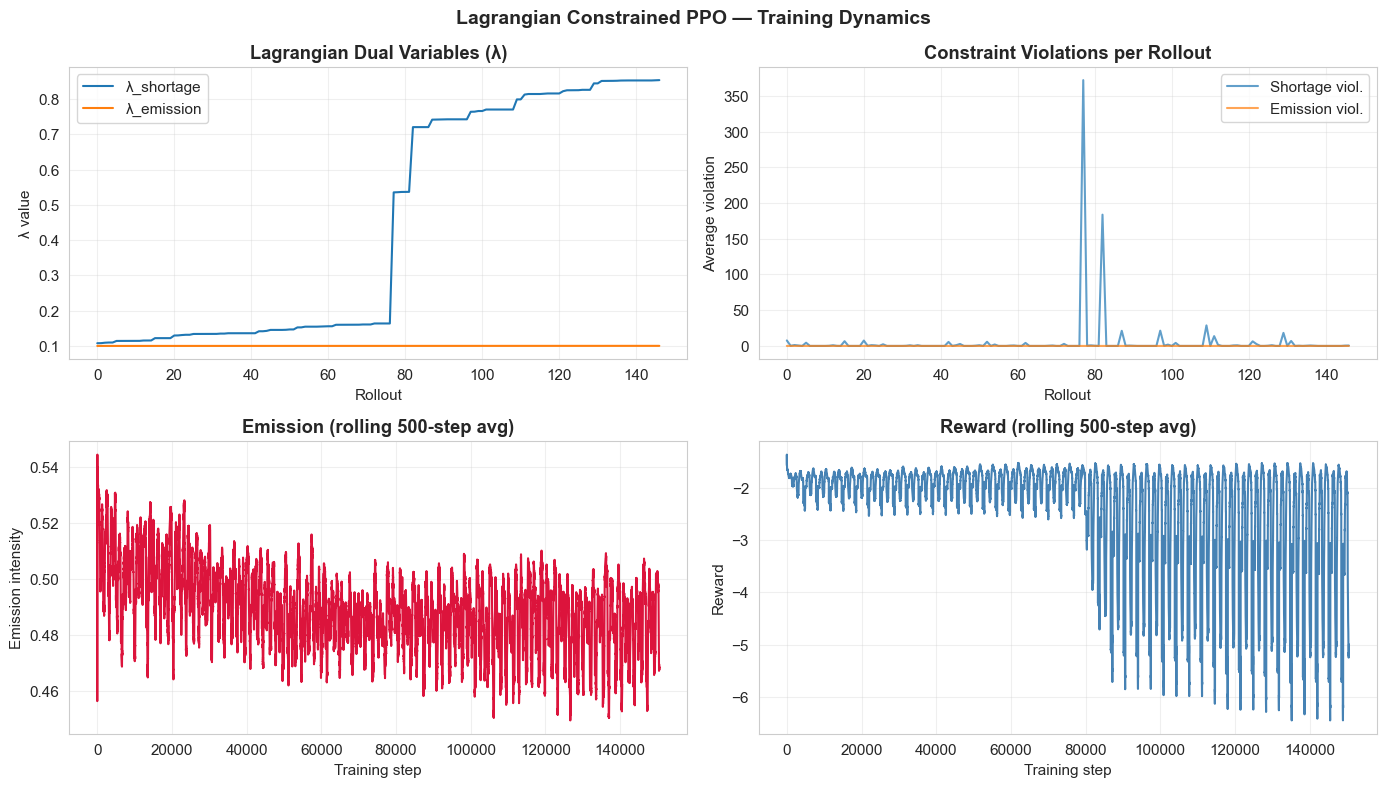

💾 Saved: 03_lagrangian_training.png


In [ ]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            g['score'] = g['emission'] * 10000   # scale
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [ ]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


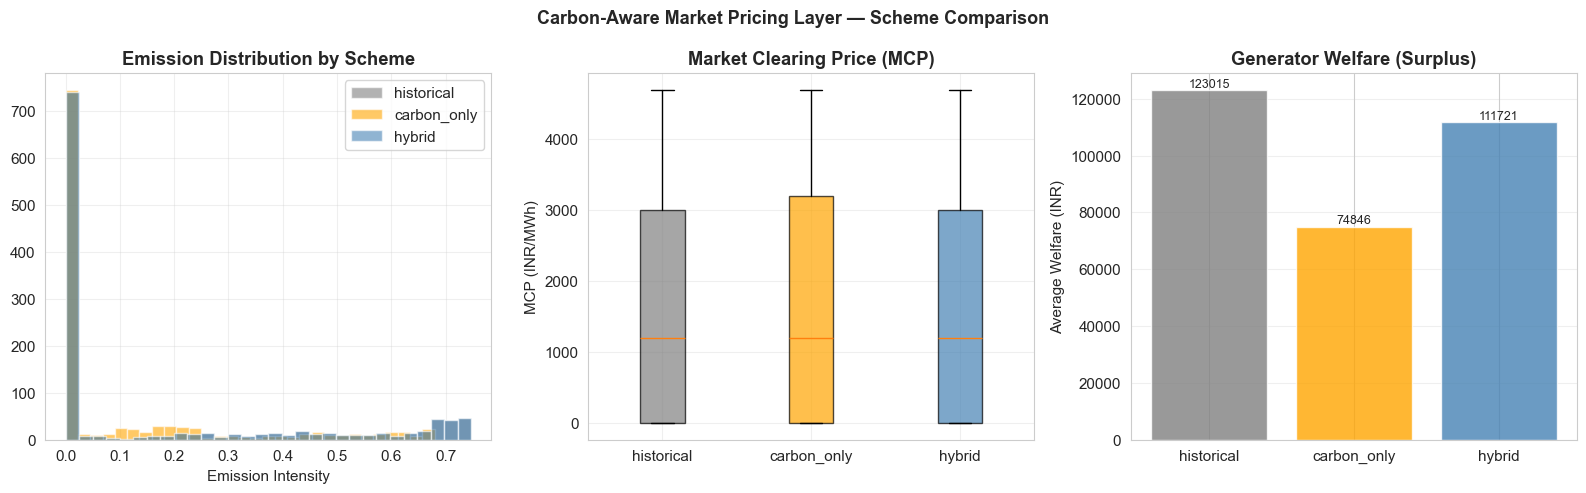

💾 Saved: 04_market_pricing.png


In [ ]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [ ]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [ ]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [ ]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


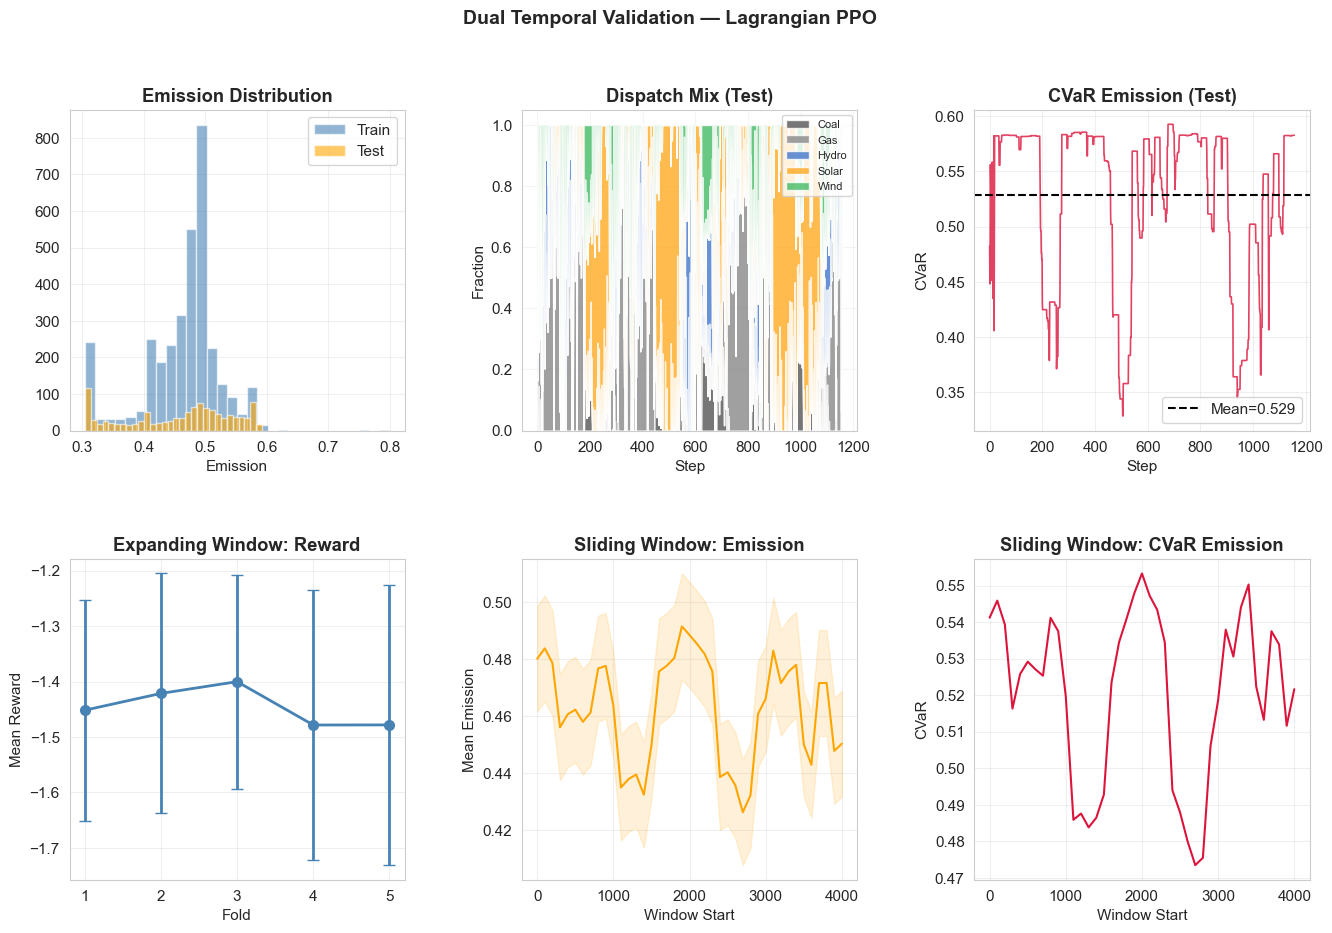

💾 Saved: 05_dual_temporal_validation.png


In [ ]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

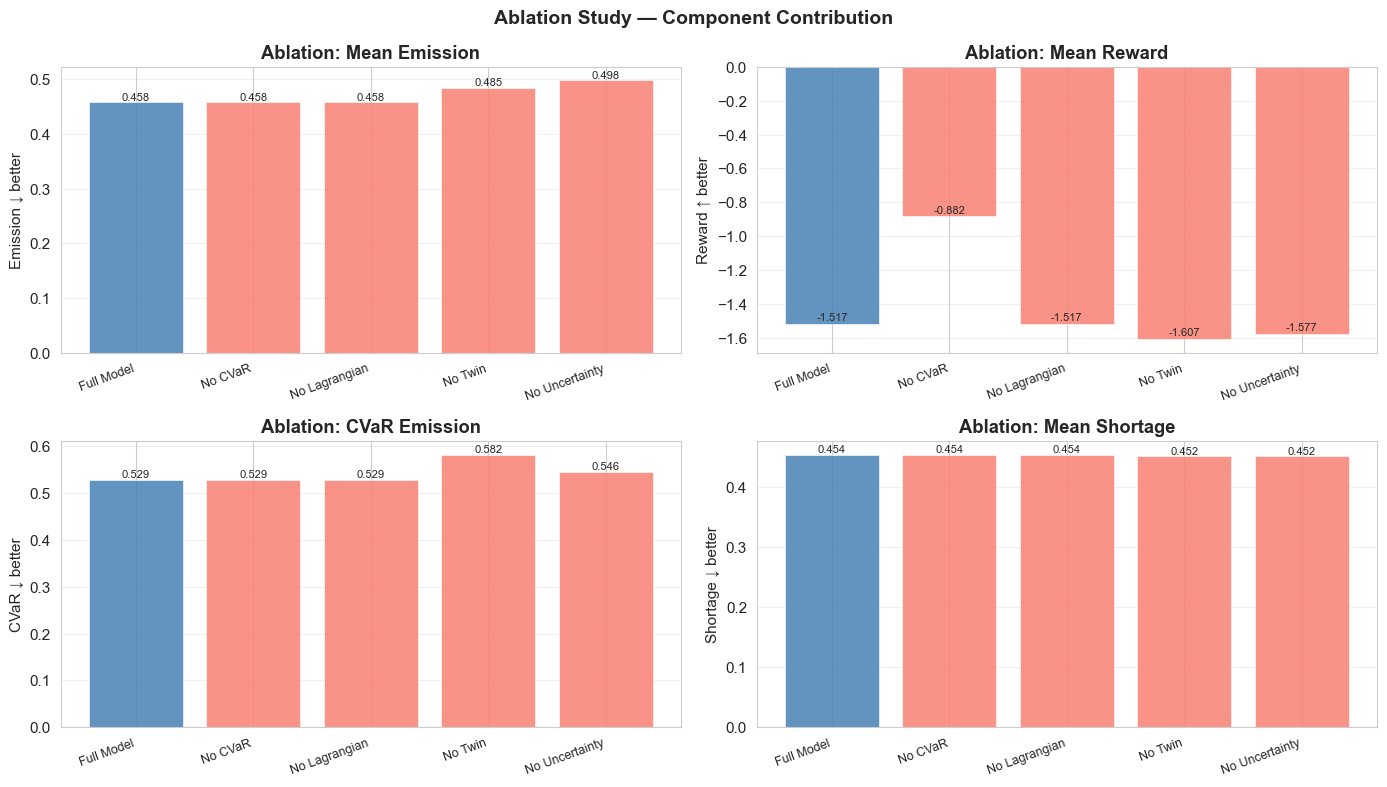

💾 Saved: 06_ablation_study.png


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [ ]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$

In [7]:
print(train_df.columns.tolist())

['date', 'state_name', 'total_generation_mwh', 'consumption_mwh', 'renewable_ratio', 'avg_coal_stock_days', 'coal_available_flag', 'supply_demand_gap', 'log_outage_ratio', 'outage_ratio_roll_mean_7', 'outage_ratio_roll_std_7', 'log_price', 'avg_market_price_roll_std_7', 'price_momentum_7', 'demand_growth', 'consumption_mwh_roll_std_7', 'post_2021_regime', 'state_id', 'outage_ratio', 'emission_intensity', 'coal_dominance', 'cap_util', 'sin_doy', 'cos_doy']


In [8]:
# ── TRAIN Carbon Digital Twin ──────────────────────────────────────────
print("=" * 60)
print("🌍 TRAINING CARBON DIGITAL TWIN")
print("=" * 60)

SEQ = CONFIG['twin_seq_len']

# Build sequences
X_tr, y_tr, scaler_twin_X, scaler_twin_y = build_sequences(
    train_df, TWIN_FEATURES, TWIN_TARGET, SEQ
)
X_te, y_te, _, _ = build_sequences(
    test_df, TWIN_FEATURES, TWIN_TARGET, SEQ,
    scaler_X=scaler_twin_X, scaler_y=scaler_twin_y
)

tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
tr_loader = DataLoader(tr_ds, batch_size=CONFIG['twin_batch'], shuffle=True)
te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

# Model
twin_model = CarbonDigitalTwin(
    input_dim=len(TWIN_FEATURES),
    hidden=CONFIG['twin_hidden'],
    n_layers=CONFIG['twin_layers']
).to(device)

twin_optimizer = optim.Adam(twin_model.parameters(), lr=CONFIG['twin_lr'])
twin_scheduler = optim.lr_scheduler.ReduceLROnPlateau(twin_optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val = np.inf

for epoch in range(CONFIG['twin_epochs']):
    twin_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        twin_optimizer.zero_grad()
        mean, logvar = twin_model(xb)
        loss = heteroscedastic_loss(mean, logvar, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(twin_model.parameters(), 1.0)
        twin_optimizer.step()
        epoch_loss += loss.item()

    # Validation
    twin_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in te_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = twin_model(xb)
            val_loss += heteroscedastic_loss(mean, logvar, yb).item()

    train_losses.append(epoch_loss / len(tr_loader))
    val_losses.append(val_loss / len(te_loader))
    twin_scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(twin_model.state_dict(), os.path.join(MODELS_DIR, 'carbon_twin_best.pt'))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{CONFIG['twin_epochs']} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# Load best
twin_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'carbon_twin_best.pt'), map_location=device))
print(f"\n✅ Carbon Digital Twin trained. Best Val Loss: {best_val:.4f}")

🌍 TRAINING CARBON DIGITAL TWIN
  Epoch  10/60 | Train: -4.1112 | Val: -0.7253
  Epoch  20/60 | Train: -4.4869 | Val: -4.5915
  Epoch  30/60 | Train: -4.7045 | Val: 14261.8522
  Epoch  40/60 | Train: -4.4698 | Val: 245438.5488
  Epoch  50/60 | Train: -5.0150 | Val: 1337499.2322
  Epoch  60/60 | Train: -5.1329 | Val: 2782932.4706

✅ Carbon Digital Twin trained. Best Val Loss: -4.8662



📊 Carbon Digital Twin Test Metrics:
   RMSE: 0.2767
   MAE : 0.1794
   R²  : 0.1992

📊 Marginal Carbon Intensity (MCI):
   Mean MCI: 0.0040
   Std  MCI: 0.0020
   (Positive gradient = more coal → more emission ✅)


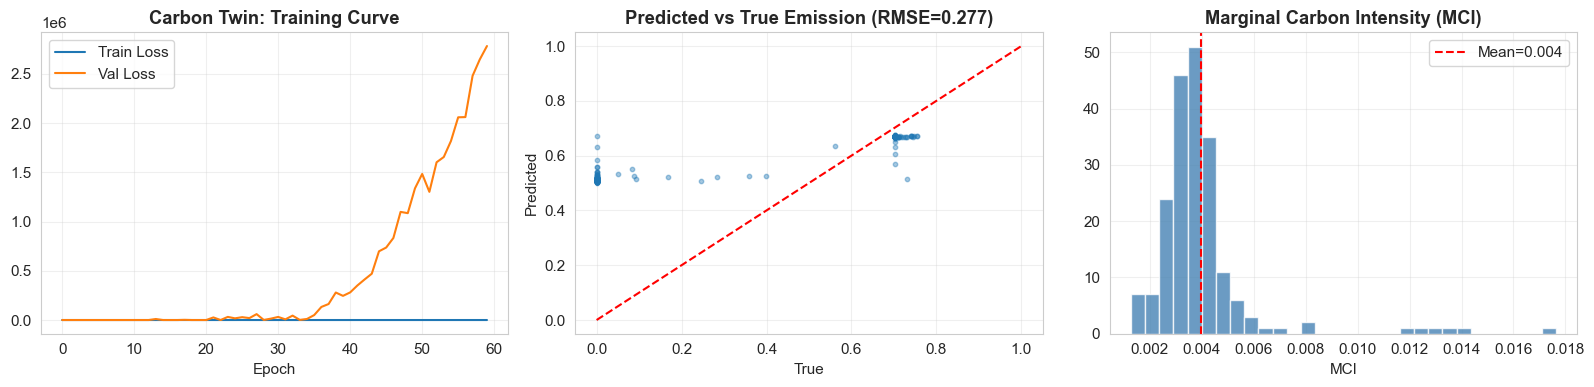

💾 Saved: 01_carbon_twin.png


In [9]:
# ── Evaluate Twin + Compute Marginal Carbon Intensity (MCI) ───────────
from sklearn.metrics import r2_score

twin_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        mean, _ = twin_model(xb)
        preds = torch.sigmoid(mean).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)
r2   = r2_score(all_true, all_preds)

print(f"\n📊 Carbon Digital Twin Test Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE : {mae:.4f}")
print(f"   R²  : {r2:.4f}")

# ── Marginal Carbon Intensity via gradient ────────────────────────────
# MCI = ∂E/∂G_coal  ≈ ∂E/∂coal_dominance (proxy)
def compute_mci(twin_model, X_seq, feature_idx_coal_dominance):
    """Compute MCI as gradient of predicted emission w.r.t. coal dominance feature."""
    
    twin_model.train()  # 🔥 IMPORTANT: must be train() for RNN backward
    
    X_tensor = torch.FloatTensor(X_seq).to(device)
    X_tensor.requires_grad_(True)

    mean, _ = twin_model(X_tensor)
    emission = torch.sigmoid(mean).sum()
    
    twin_model.zero_grad()
    emission.backward()

    grad = X_tensor.grad[:, -1, feature_idx_coal_dominance].detach().cpu().numpy()

    twin_model.eval()  # switch back to eval after computing gradient
    
    return grad

coal_dom_idx = TWIN_FEATURES.index('coal_dominance')
# Sample MCI on first 200 test windows
mci_vals = compute_mci(twin_model, X_te[:200], coal_dom_idx)
print(f"\n📊 Marginal Carbon Intensity (MCI):")
print(f"   Mean MCI: {mci_vals.mean():.4f}")
print(f"   Std  MCI: {mci_vals.std():.4f}")
print(f"   (Positive gradient = more coal → more emission ✅)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Carbon Twin: Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pred vs True
axes[1].scatter(all_true[:300], all_preds[:300], alpha=0.4, s=10)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title(f'Predicted vs True Emission (RMSE={rmse:.3f})', fontweight='bold')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].grid(alpha=0.3)

# MCI distribution
axes[2].hist(mci_vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(mci_vals.mean(), color='red', linestyle='--', label=f'Mean={mci_vals.mean():.3f}')
axes[2].set_title('Marginal Carbon Intensity (MCI)', fontweight='bold')
axes[2].set_xlabel('MCI'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_carbon_twin.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 01_carbon_twin.png")

## 4. COMPONENT 2 — Probabilistic Quantile Forecaster

We train a quantile regression LSTM to produce uncertainty-aware predictions:
$$D_t \sim P(D_t \mid W_t, \text{season}, \text{history}) \quad \text{via quantiles } q_{0.05}, q_{0.5}, q_{0.95}$$

The RL agent will receive $(\mu, q_{0.05}, q_{0.95})$ as part of its state.

In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  QUANTILE FORECASTER  —  Pinball loss LSTM
# ═══════════════════════════════════════════════════════════════════════

class QuantileForecaster(nn.Module):
    """
    LSTM that outputs multiple quantile predictions.
    Loss: Pinball loss  L(τ) = max(τ(y-ŷ), (τ-1)(y-ŷ))
    """
    def __init__(self, input_dim, hidden=64, n_layers=2, quantiles=[0.05, 0.5, 0.95]):
        super().__init__()
        self.quantiles = quantiles
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
            for _ in quantiles
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return torch.cat([h(last) for h in self.heads], dim=-1)  # (B, Q)


def pinball_loss(preds, targets, quantiles):
    """
    preds: (batch_size, num_quantiles)
    targets: (batch_size,)
    quantiles: list like [0.05, 0.5, 0.95]
    """
    total_loss = 0.0
    
    for i, tau in enumerate(quantiles):
        errors = targets - preds[:, i]
        loss = torch.max(tau * errors, (tau - 1) * errors)
        total_loss += torch.mean(loss)
    
    return total_loss / len(quantiles)


def train_quantile_forecaster(df_tr, df_te, feature_cols, target_col, cfg):
    """
    Train and return a QuantileForecaster for `target_col`.
    Returns: (model, scaler_X, scaler_y, calibration_dict)
    """
    SEQ = cfg['qf_seq_len']
    quantiles = cfg['quantiles']

    X_tr, y_tr, sc_X, sc_y = build_sequences(df_tr, feature_cols, target_col, SEQ)
    X_te, y_te, _,   _    = build_sequences(df_te, feature_cols, target_col, SEQ,
                                              scaler_X=sc_X, scaler_y=sc_y)

    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_loader = DataLoader(tr_ds, batch_size=cfg['qf_batch'], shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)

    model = QuantileForecaster(
        input_dim=len(feature_cols), hidden=cfg['qf_hidden'],
        quantiles=quantiles
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['qf_lr'])

    best_val, best_state = np.inf, None
    for epoch in range(cfg['qf_epochs']):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss  = pinball_loss(preds, yb, quantiles)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        all_q = []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += pinball_loss(preds, yb, quantiles).item()
                all_q.append(preds.cpu().numpy())
        val_loss /= len(te_loader)
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # Calibration: measure interval coverage
    all_q = np.concatenate(all_q, axis=0)
    # Inverse-transform
    q_lo = sc_y.inverse_transform(all_q[:, 0].reshape(-1,1)).flatten()
    q_hi = sc_y.inverse_transform(all_q[:, 2].reshape(-1,1)).flatten()
    y_true_orig = sc_y.inverse_transform(y_te[:len(all_q)].reshape(-1,1)).flatten()
    coverage = np.mean((y_true_orig >= q_lo) & (y_true_orig <= q_hi))
    calib = {'target_coverage': 0.90, 'actual_coverage': float(coverage), 'best_val_loss': float(best_val)}

    return model, sc_X, sc_y, calib


print("✅ QuantileForecaster class and training function defined")

✅ QuantileForecaster class and training function defined


In [11]:
print("=" * 60)
print("📈 TRAINING QUANTILE FORECASTERS")
print("=" * 60)

# ── Demand forecaster ─────────────────────────────────────────────────
print("\n[1/2] Demand Forecaster...")
qf_demand, sc_qf_demand_X, sc_qf_demand_y, calib_demand = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_demand['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_demand['actual_coverage']:.3f} (target: 0.90)")

# ── Renewable forecaster ──────────────────────────────────────────────
print("\n[2/2] Renewable Ratio Forecaster...")
qf_renew, sc_qf_renew_X, sc_qf_renew_y, calib_renew = train_quantile_forecaster(
    train_df, test_df, QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG   # ✅ changed here
)
print(f"  Best Val Loss: {calib_renew['best_val_loss']:.4f}")
print(f"  90% Interval Coverage: {calib_renew['actual_coverage']:.3f} (target: 0.90)")

print("\n✅ Both quantile forecasters trained")

# Save
torch.save(qf_demand.state_dict(), os.path.join(MODELS_DIR, 'qf_demand.pt'))
torch.save(qf_renew.state_dict(),  os.path.join(MODELS_DIR, 'qf_renew.pt'))

joblib.dump(
    {'sc_X': sc_qf_demand_X, 'sc_y': sc_qf_demand_y},
    os.path.join(MODELS_DIR, 'qf_demand_scalers.pkl')
)

joblib.dump(
    {'sc_X': sc_qf_renew_X, 'sc_y': sc_qf_renew_y},
    os.path.join(MODELS_DIR, 'qf_renew_scalers.pkl')
)

📈 TRAINING QUANTILE FORECASTERS

[1/2] Demand Forecaster...
  Best Val Loss: 0.0390
  90% Interval Coverage: 0.525 (target: 0.90)

[2/2] Renewable Ratio Forecaster...
  Best Val Loss: 0.0406
  90% Interval Coverage: 0.259 (target: 0.90)

✅ Both quantile forecasters trained


['c:\\Users\\Ohi\\Desktop\\m\\final_RL_V2\\results\\models\\qf_renew_scalers.pkl']

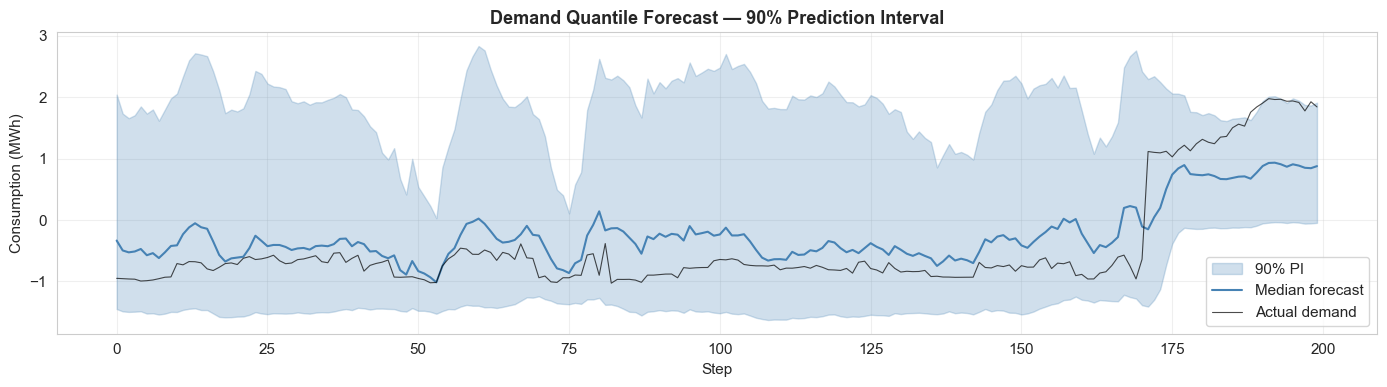

💾 Saved: 02_quantile_forecast.png


In [12]:
# ── Visualise quantile predictions ────────────────────────────────────
SEQ_QF = CONFIG['qf_seq_len']
X_te_qf, y_te_qf, _, _ = build_sequences(
    test_df, QF_INPUT_DEMAND, QF_TARGET_DEMAND, SEQ_QF,
    scaler_X=sc_qf_demand_X, scaler_y=sc_qf_demand_y
)
qf_demand.eval()
with torch.no_grad():
    q_out = qf_demand(torch.FloatTensor(X_te_qf[:200]).to(device)).cpu().numpy()

# Inverse transform
q_lo = sc_qf_demand_y.inverse_transform(q_out[:, 0].reshape(-1,1)).flatten()
q_mid= sc_qf_demand_y.inverse_transform(q_out[:, 1].reshape(-1,1)).flatten()
q_hi = sc_qf_demand_y.inverse_transform(q_out[:, 2].reshape(-1,1)).flatten()
y_true_orig = sc_qf_demand_y.inverse_transform(y_te_qf[:200].reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(q_mid))
ax.fill_between(t, q_lo, q_hi, alpha=0.25, color='steelblue', label='90% PI')
ax.plot(t, q_mid, color='steelblue', linewidth=1.5, label='Median forecast')
ax.plot(t, y_true_orig, color='black', linewidth=0.8, alpha=0.7, label='Actual demand')
ax.set_title('Demand Quantile Forecast — 90% Prediction Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Consumption (MWh)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_quantile_forecast.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 02_quantile_forecast.png")

## 5. Pre-compute Quantile Embeddings for RL State

The RL state will include uncertainty information: $(q_{0.05}, q_{0.5}, q_{0.95})$ for both demand and renewables.
These 6 values augment the base state features.

In [13]:
def compute_quantile_embeddings(df, qf_model, sc_X, sc_y, feature_cols, target_col, seq_len):
    """
    Compute quantile forecasts for every row in df (with padding for first seq_len rows).
    Returns array of shape (len(df), 3) = [q05, q50, q95]
    """
    X_all, _, _, _ = build_sequences(df, feature_cols, target_col, seq_len,
                                      scaler_X=sc_X, scaler_y=sc_y)
    qf_model.eval()
    with torch.no_grad():
        q_raw = qf_model(torch.FloatTensor(X_all).to(device)).cpu().numpy()

    # Inverse transform each quantile
    result = np.zeros((len(df), 3), dtype=np.float32)
    for qi in range(3):
        q_inv = sc_y.inverse_transform(q_raw[:, qi].reshape(-1, 1)).flatten()
        result[seq_len:, qi] = q_inv
        result[:seq_len, qi] = q_inv[0]  # pad with first valid value
    return result

print("Computing demand quantile embeddings...")
train_q_demand = compute_quantile_embeddings(
    train_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']   
)
test_q_demand = compute_quantile_embeddings(
    test_df, qf_demand, sc_qf_demand_X, sc_qf_demand_y,
    QF_INPUT_DEMAND, QF_TARGET_DEMAND, CONFIG['qf_seq_len']  
)

print("Computing renewable quantile embeddings...")
train_q_renew = compute_quantile_embeddings(
    train_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)
test_q_renew = compute_quantile_embeddings(
    test_df, qf_renew, sc_qf_renew_X, sc_qf_renew_y,
    QF_INPUT_RENEW, QF_TARGET_RENEW, CONFIG['qf_seq_len']    
)

# Add as columns to dataframes
for i, q_name in enumerate(['q05', 'q50', 'q95']):
    train_df[f'demand_{q_name}'] = train_q_demand[:, i]
    test_df[f'demand_{q_name}']  = test_q_demand[:, i]
    train_df[f'renew_{q_name}']  = train_q_renew[:, i]
    test_df[f'renew_{q_name}']   = test_q_renew[:, i]

# Also compute Carbon Twin emission predictions
def compute_twin_predictions(df, twin_model, scaler_X, scaler_y, feature_cols, seq_len):
    X_all, _, _, _ = build_sequences(df, feature_cols, TWIN_TARGET, seq_len,
                                      scaler_X=scaler_X, scaler_y=scaler_y)
    twin_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), 128):
            xb = torch.FloatTensor(X_all[i:i+128]).to(device)
            mean, logvar = twin_model(xb)
            preds.extend(torch.sigmoid(mean).cpu().numpy())
    result = np.zeros(len(df), dtype=np.float32)
    result[seq_len:] = preds
    result[:seq_len] = preds[0]
    return result

print("Computing Carbon Twin emission predictions for RL states...")
train_df['twin_emission'] = compute_twin_predictions(
    train_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)
test_df['twin_emission'] = compute_twin_predictions(
    test_df, twin_model, scaler_twin_X, scaler_twin_y, TWIN_FEATURES, CONFIG['twin_seq_len']
)

print("\n✅ Quantile embeddings + twin emission added to DataFrames")
print(f"   New RL state dimension: {len(RL_BASE_FEATURES) + 7} (base + 6 quantiles + 1 twin emission)")

Computing demand quantile embeddings...
Computing renewable quantile embeddings...
Computing Carbon Twin emission predictions for RL states...

✅ Quantile embeddings + twin emission added to DataFrames
   New RL state dimension: 21 (base + 6 quantiles + 1 twin emission)


## 6. COMPONENT 3 — Multi-Source Dispatch Environment

Full vector action space:
$$a_t = (g_{\text{coal}}, g_{\text{gas}}, g_{\text{hydro}}, g_{\text{solar}}, g_{\text{wind}}) \in [0,1]^5$$

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  GRID DISPATCH ENVIRONMENT — Optimized & Safe Version
# ═══════════════════════════════════════════════════════════════════════

# ✅ Make sure this is defined BEFORE the class
SOURCE_EMISSIONS = {
    'coal':  1.00,
    'gas':   0.45,
    'hydro': 0.02,
    'solar': 0.01,
    'wind':  0.01,
}


class GridDispatchEnvV2(gym.Env):

    metadata = {'render_modes': []}

    def __init__(self, df, scaler=None, fit_scaler=False, config=None):
        super().__init__()

        self.df  = df.copy().reset_index(drop=True)
        self.cfg = config or {}
        self.n   = len(self.df)

        # Reward weights
        self.w_e = self.cfg.get('w_emission', 1.0)
        self.w_o = self.cfg.get('w_outage',   2.0)
        self.w_g = self.cfg.get('w_gap',      0.5)
        self.w_c = self.cfg.get('w_cvar',     1.2)
        self.w_p = self.cfg.get('w_price',    0.2)

        self.cvar_alpha  = self.cfg.get('cvar_alpha',  0.95)
        self.cvar_window = self.cfg.get('cvar_window', 20)

        self.shortage_budget = self.cfg.get('shortage_budget', 0.02)
        self.emission_budget = self.cfg.get('emission_budget', 0.70)

        self.lambda_shortage = 0.0
        self.lambda_emission = 0.0

        EXTRA = [
            'demand_q05','demand_q50','demand_q95',
            'renew_q05','renew_q50','renew_q95',
            'twin_emission'
        ]

        self.feature_cols = [
            c for c in (RL_BASE_FEATURES + EXTRA)
            if c in self.df.columns
        ]

        # Scaler
        if scaler is None:
            self.scaler = StandardScaler()
            if fit_scaler:
                self.scaler.fit(self.df[self.feature_cols].values)
        else:
            self.scaler = scaler

        self.df_norm = self.df.copy()
        self.df_norm[self.feature_cols] = self.scaler.transform(
            self.df[self.feature_cols].fillna(0).values
        )

        # 🔥 Precompute NumPy arrays (major speed fix)
        self.obs_array        = self.df_norm[self.feature_cols].values.astype(np.float32)
        self.consumption_arr  = self.df['consumption_mwh'].values.astype(np.float32)
        self.total_gen_arr    = self.df['total_generation_mwh'].values.astype(np.float32)
        self.gap_arr          = self.df['supply_demand_gap'].values.astype(np.float32)
        self.outage_arr       = self.df['outage_ratio'].values.astype(np.float32)

        if 'twin_emission' in self.df.columns:
            self.twin_arr = self.df['twin_emission'].values.astype(np.float32)
        else:
            self.twin_arr = None

        if 'price_momentum_7' in self.df.columns:
            self.price_vol_arr = np.abs(self.df['price_momentum_7'].values.astype(np.float32))
        else:
            self.price_vol_arr = np.zeros(self.n, dtype=np.float32)

        self.emission_vec = np.array(
            [SOURCE_EMISSIONS[k] for k in ['coal','gas','hydro','solar','wind']],
            dtype=np.float32
        )

        obs_dim = len(self.feature_cols)
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(0., 1., shape=(5,), dtype=np.float32)

        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_num = 0
        self.emission_history = []
        self.shortage_history = []
        return self.obs_array[self.step_num], {'step': 0}

    def step(self, action):

        idx = self.step_num

        action = np.clip(np.array(action, dtype=np.float32), 0, 1)
        dispatch = action / (action.sum() + 1e-8)

        dispatch_emission = float(np.dot(dispatch, self.emission_vec))

        twin_pred = (
            float(self.twin_arr[idx])
            if self.twin_arr is not None
            else dispatch_emission
        )

        emission = 0.6 * twin_pred + 0.4 * dispatch_emission

        demand    = float(self.consumption_arr[idx])
        total_gen = float(self.total_gen_arr[idx])
        gap       = float(self.gap_arr[idx])
        outage    = float(self.outage_arr[idx])

        supply   = total_gen * (1.0 - dispatch[0] * 0.1)
        shortage = max(0.0, demand - supply) / (demand + 1e-6)

        price_vol = float(self.price_vol_arr[idx])

        self.emission_history.append(emission)
        self.shortage_history.append(shortage)

        if len(self.emission_history) >= self.cvar_window:
            recent = self.emission_history[-self.cvar_window:]
            var    = np.quantile(recent, self.cvar_alpha)
            cvar   = float(np.mean([e for e in recent if e >= var]))
        else:
            cvar = emission

        shortage_violation = max(0.0, shortage - self.shortage_budget)
        emission_violation = max(0.0, emission - self.emission_budget)

        lagrangian_penalty = (
            self.lambda_shortage * shortage_violation +
            self.lambda_emission * emission_violation
        )

        reward = (
            - self.w_e * emission
            - self.w_o * min(outage, 5.0)
            - self.w_g * abs(gap) / (abs(gap) + 1.0)
            - self.w_c * cvar
            - self.w_p * price_vol
            - lagrangian_penalty
        )

        self.step_num += 1
        terminated = self.step_num >= self.n
        truncated  = False

        obs = (
            self.obs_array[self.step_num]
            if not terminated
            else np.zeros(len(self.feature_cols), dtype=np.float32)
        )

        info = {
            'step': self.step_num,
            'emission': emission,
            'twin_emission': twin_pred,
            'dispatch': dispatch.tolist(),
            'shortage': shortage,
            'outage': outage,
            'cvar': cvar,
            'gap': gap,
            'lagrangian_penalty': lagrangian_penalty,
            'shortage_violation': shortage_violation,
            'emission_violation': emission_violation,
        }

        return obs, reward, terminated, truncated, info


print("✅ Optimized GridDispatchEnvV2 ready")

✅ Optimized GridDispatchEnvV2 ready


## 7. COMPONENT 4 — Lagrangian Constrained PPO

Standard SB3 PPO is augmented with a dual-variable update loop:
$$\lambda_{k+1} = \max(0,\; \lambda_k + \eta \cdot \text{violation}_k)$$
The environment's `lambda_shortage` and `lambda_emission` attributes are updated every rollout.

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  LAGRANGIAN CONSTRAINED PPO TRAINER (Optimized)
# ═══════════════════════════════════════════════════════════════════════

class LagrangianCallback(BaseCallback):

    def __init__(self, env_ref, cfg, verbose=0):
        super().__init__(verbose)
        self.env_ref = env_ref
        self.lambda_lr = cfg.get('lambda_lr', 0.01)
        self.lambda_shortage = cfg.get('lambda_init', 0.1)
        self.lambda_emission = cfg.get('lambda_init', 0.1)

        self.history = {
            'lambda_s': [],
            'lambda_e': [],
            'violation_s': [],
            'violation_e': []
        }

    def _on_rollout_end(self) -> None:

        infos = self.locals.get('infos', None)
        if infos is None or len(infos) == 0:
            return

        # 🔥 Faster accumulation (no list creation)
        total_sv = 0.0
        total_ev = 0.0
        n = len(infos)

        for i in infos:
            total_sv += i.get('shortage_violation', 0.0)
            total_ev += i.get('emission_violation', 0.0)

        avg_sv = total_sv / n
        avg_ev = total_ev / n

        # Dual update
        self.lambda_shortage = max(0.0, self.lambda_shortage + self.lambda_lr * avg_sv)
        self.lambda_emission = max(0.0, self.lambda_emission + self.lambda_lr * avg_ev)

        # Clamp
        if self.lambda_shortage > 5.0:
            self.lambda_shortage = 5.0
        if self.lambda_emission > 5.0:
            self.lambda_emission = 5.0

        # Inject λ into environments
        for env in self.training_env.envs:
            env.lambda_shortage = self.lambda_shortage
            env.lambda_emission = self.lambda_emission

        # Log
        self.history['lambda_s'].append(self.lambda_shortage)
        self.history['lambda_e'].append(self.lambda_emission)
        self.history['violation_s'].append(avg_sv)
        self.history['violation_e'].append(avg_ev)

        if self.verbose and len(self.history['lambda_s']) % 10 == 0:
            print(
                f"   [Lagrange] λ_s={self.lambda_shortage:.3f}  "
                f"λ_e={self.lambda_emission:.3f}  "
                f"viol_s={avg_sv:.4f}  viol_e={avg_ev:.4f}"
            )

    def _on_step(self) -> bool:
        return True


class MetricsCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.emissions = []
        self.rewards   = []
        self.shortages = []
        self.cvars     = []

    def _on_step(self) -> bool:

        infos = self.locals.get('infos', None)
        if infos is None:
            return True

        rewards = self.locals.get('rewards', None)

        for idx, info in enumerate(infos):
            self.emissions.append(info.get('emission', 0.0))
            self.shortages.append(info.get('shortage', 0.0))
            self.cvars.append(info.get('cvar', 0.0))

            if rewards is not None:
                self.rewards.append(rewards[idx])

        return True


print("✅ Optimized LagrangianCallback and MetricsCallback defined")

✅ Optimized LagrangianCallback and MetricsCallback defined


In [16]:
# ── Build environments ────────────────────────────────────────────────
print("🏗️  Building environments...")

# Fit scaler on train
ref_env = GridDispatchEnvV2(train_df, fit_scaler=True, config=CONFIG)
rl_scaler = ref_env.scaler
joblib.dump(rl_scaler, os.path.join(MODELS_DIR, 'rl_scaler.pkl'))

def make_env_v2(df, scaler, cfg):
    def _init():
        return GridDispatchEnvV2(df, scaler=scaler, config=cfg)
    return _init

train_vec = DummyVecEnv([make_env_v2(train_df, rl_scaler, CONFIG)])
eval_vec  = DummyVecEnv([make_env_v2(test_df,  rl_scaler, CONFIG)])

# ── Callbacks ─────────────────────────────────────────────────────────
lagrangian_cb = LagrangianCallback(ref_env, CONFIG, verbose=1)
metrics_cb    = MetricsCallback()

checkpoint_cb = CheckpointCallback(
    save_freq=CONFIG['checkpoint_freq'],
    save_path=MODELS_DIR,
    name_prefix='ppo_v2',
    verbose=0
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=MODELS_DIR,
    log_path=LOGS_DIR,
    eval_freq=CONFIG['eval_freq'],
    n_eval_episodes=CONFIG['n_eval_episodes'],
    deterministic=True,
    verbose=0
)

# ── PPO model ─────────────────────────────────────────
model = PPO(
    policy='MlpPolicy',
    env=train_vec,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],          # ✅ now from config
    batch_size=CONFIG['batch_size'],
    n_epochs=CONFIG['n_epochs'],        # ✅ now from config
    gamma=CONFIG['gamma'],
    gae_lambda=CONFIG['gae_lambda'],
    clip_range=CONFIG['clip_range'],
    ent_coef=CONFIG['ent_coef'],
    verbose=0,
    tensorboard_log=None,
    seed=CONFIG['seed'],
    policy_kwargs={'net_arch': [128, 128]},
    device=device                       # ✅ GPU forced
)

print(f"✅ Lagrangian-PPO ready")
print(f"   Policy network: [128, 128]")
print(f"   Obs dim: {model.observation_space.shape[0]}")
print(f"   Action dim: {model.action_space.shape[0]} (5 source dispatch)")
print(f"   Device: {model.device}")

🏗️  Building environments...
✅ Lagrangian-PPO ready
   Policy network: [128, 128]
   Obs dim: 21
   Action dim: 5 (5 source dispatch)
   Device: cuda


In [17]:
import sys
print(sys.executable)
print(model.device)

c:\Users\Ohi\Desktop\m\final_RL_V2\venv\Scripts\python.exe
cuda


In [18]:
print("\n" + "="*60)
print("🚀 TRAINING LAGRANGIAN CONSTRAINED PPO")
print("="*60)
print(f"Total timesteps: {CONFIG['total_timesteps']:,}")
print(f"Dual updates at every rollout ({CONFIG['n_steps']} steps)")
print("="*60)

start = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[lagrangian_cb, metrics_cb, checkpoint_cb, eval_cb],
    progress_bar=False
)
elapsed = time.time() - start

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Final λ_shortage: {lagrangian_cb.lambda_shortage:.4f}")
print(f"   Final λ_emission: {lagrangian_cb.lambda_emission:.4f}")

# Save
model.save(os.path.join(MODELS_DIR, 'ppo_lagrangian_final.zip'))
print(f"💾 Model saved")


🚀 TRAINING LAGRANGIAN CONSTRAINED PPO
Total timesteps: 150,000
Dual updates at every rollout (1024 steps)
   [Lagrange] λ_s=0.114  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.122  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.134  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.136  λ_e=0.100  viol_s=0.0343  viol_e=0.0000
   [Lagrange] λ_s=0.146  λ_e=0.100  viol_s=0.3357  viol_e=0.0000
   [Lagrange] λ_s=0.156  λ_e=0.100  viol_s=0.6329  viol_e=0.0000
   [Lagrange] λ_s=0.161  λ_e=0.100  viol_s=0.5872  viol_e=0.0708
   [Lagrange] λ_s=0.537  λ_e=0.100  viol_s=0.7423  viol_e=0.0000
   [Lagrange] λ_s=0.743  λ_e=0.100  viol_s=0.4658  viol_e=0.0000
   [Lagrange] λ_s=0.766  λ_e=0.100  viol_s=1.8524  viol_e=0.0000
   [Lagrange] λ_s=0.799  λ_e=0.100  viol_s=28.7459  viol_e=0.0000
   [Lagrange] λ_s=0.816  λ_e=0.100  viol_s=0.0000  viol_e=0.0000
   [Lagrange] λ_s=0.845  λ_e=0.100  viol_s=18.2542  viol_e=0.0000
   [Lagrange] λ_s=0.853  λ_e=0.100  viol_s=0.0

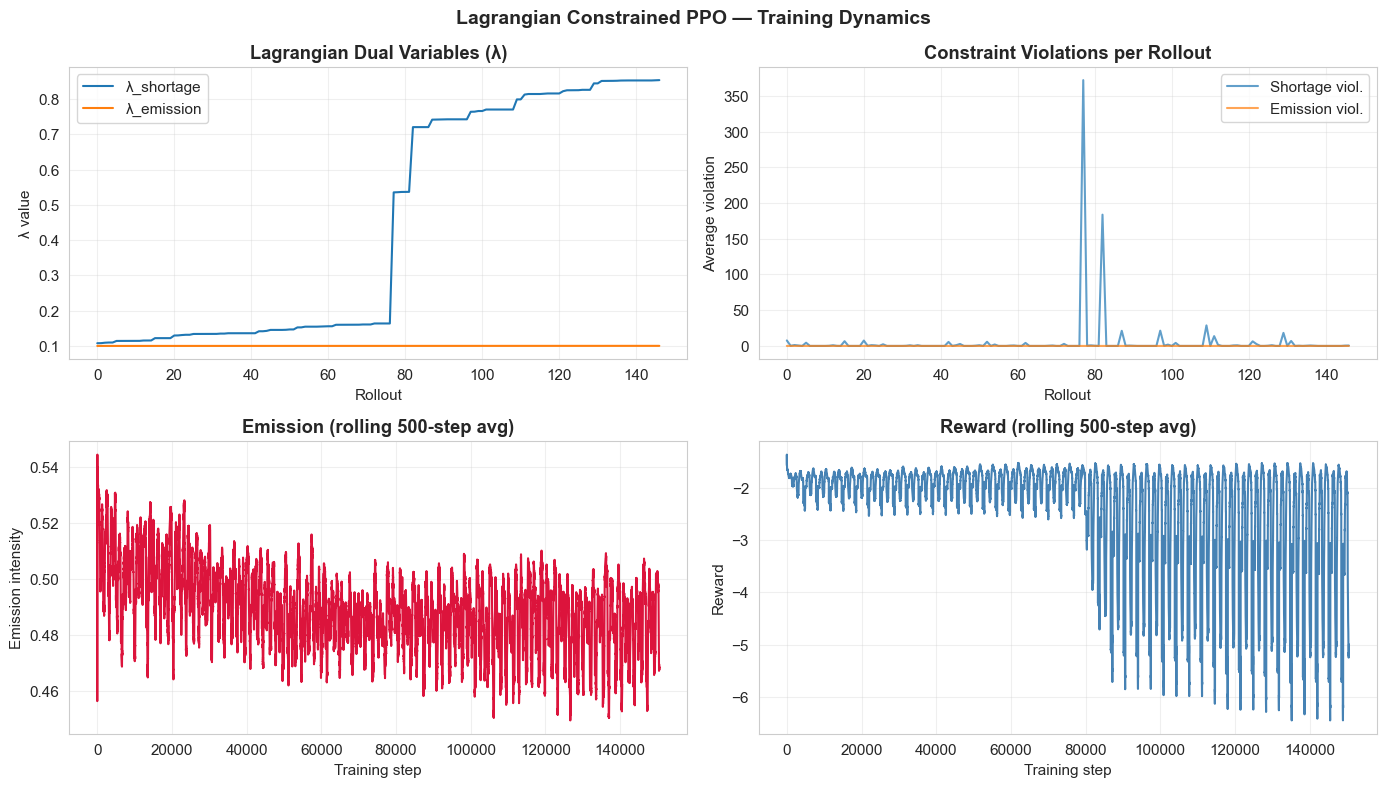

💾 Saved: 03_lagrangian_training.png


In [19]:
# ── Visualise training convergence ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dual variables over rollouts
axes[0,0].plot(lagrangian_cb.history['lambda_s'], label='λ_shortage')
axes[0,0].plot(lagrangian_cb.history['lambda_e'], label='λ_emission')
axes[0,0].set_title('Lagrangian Dual Variables (λ)', fontweight='bold')
axes[0,0].set_xlabel('Rollout'); axes[0,0].set_ylabel('λ value')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Violations
axes[0,1].plot(lagrangian_cb.history['violation_s'], label='Shortage viol.', alpha=0.7)
axes[0,1].plot(lagrangian_cb.history['violation_e'], label='Emission viol.', alpha=0.7)
axes[0,1].set_title('Constraint Violations per Rollout', fontweight='bold')
axes[0,1].set_xlabel('Rollout'); axes[0,1].set_ylabel('Average violation')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Emission over training steps
if metrics_cb.emissions:
    window = 500
    em_smooth = pd.Series(metrics_cb.emissions).rolling(window, min_periods=1).mean()
    axes[1,0].plot(em_smooth, color='crimson', linewidth=1.5)
    axes[1,0].set_title(f'Emission (rolling {window}-step avg)', fontweight='bold')
    axes[1,0].set_xlabel('Training step'); axes[1,0].set_ylabel('Emission intensity')
    axes[1,0].grid(alpha=0.3)

# Reward over training steps
if metrics_cb.rewards:
    rw_smooth = pd.Series(metrics_cb.rewards).rolling(window, min_periods=1).mean()
    axes[1,1].plot(rw_smooth, color='steelblue', linewidth=1.5)
    axes[1,1].set_title(f'Reward (rolling {window}-step avg)', fontweight='bold')
    axes[1,1].set_xlabel('Training step'); axes[1,1].set_ylabel('Reward')
    axes[1,1].grid(alpha=0.3)

plt.suptitle('Lagrangian Constrained PPO — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_lagrangian_training.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 03_lagrangian_training.png")

## 8. COMPONENT 5 — Market Pricing Layer

Carbon-adjusted merit order dispatch:
$$\text{Score}_i = b_i + \gamma \cdot \epsilon_i$$
$$\text{Payment}_i = \text{MCP} - \delta \cdot \epsilon_i$$

In [22]:
# ═══════════════════════════════════════════════════════════════════════
#  MARKET PRICING LAYER
# ═══════════════════════════════════════════════════════════════════════

# Synthetic generator fleet (representative of India's grid)
GENERATORS = pd.DataFrame({
    'name':      ['Coal-1', 'Coal-2', 'Gas-1', 'Gas-2', 'Hydro', 'Solar', 'Wind'],
    'source':    ['coal',   'coal',   'gas',   'gas',   'hydro', 'solar', 'wind'],
    'capacity':  [200,       150,       80,      60,      50,      40,      30],   # MW
    'base_bid':  [3000,      3200,     4500,    4700,    1500,    1200,    1100],   # INR/MWh
    'emission':  [1.00,      1.00,     0.45,    0.45,    0.02,    0.01,    0.01],  # relative
})


class CarbonAwareMarket:
    """
    Simulates a carbon-adjusted merit order electricity market.

    Schemes:
      1. Historical: sort by base_bid only
      2. Carbon-Only: sort by emission only
      3. Hybrid (proposed): sort by bid + γ*emission
         Payment: MCP - δ*emission (carbon rebate for clean generators)
    """

    def __init__(self, generators_df, gamma=0.15, delta=0.05):
        self.gens  = generators_df.copy()
        self.gamma = gamma   # carbon price weight
        self.delta = delta   # rebate factor

    def _clear_market(self, scheme, demand):
        g = self.gens.copy()
        if scheme == 'historical':
            g['score'] = g['base_bid']
        elif scheme == 'carbon_only':
            g['score'] = g['emission'] * 10000   # scale
        elif scheme == 'hybrid':
            g['score'] = g['base_bid'] + self.gamma * g['emission'] * 10000
        else:
            raise ValueError(scheme)

        g = g.sort_values('score').reset_index(drop=True)

        # Merit order dispatch until demand is met
        dispatched, cum = [], 0.0
        mcp = g['base_bid'].max()
        for _, row in g.iterrows():
            if cum >= demand:
                break
            accept = min(row['capacity'], demand - cum)
            cum += accept
            dispatched.append(row.to_dict() | {'accepted_mw': accept})
            mcp = row['base_bid']

        d = pd.DataFrame(dispatched)

        if d.empty:
            return {
                'scheme': scheme,
                'mcp': 0.0,
                'dispatched_mw': 0.0,
                'total_emission': 0.0,
                'welfare': 0.0,
                'price_volatility': 0.0,
                'n_generators': 0,
                'detail': d,
            }

        # Define payment FIRST
        if scheme == 'hybrid':
            d['payment'] = mcp - self.delta * d['emission'] * mcp
        else:
            d['payment'] = mcp

        # Metrics
        total_emission = (d['emission'] * d['accepted_mw']).sum() / (d['accepted_mw'].sum() + 1e-6)
        welfare        = ((d['payment'] - d['base_bid']) * d['accepted_mw']).sum()  # generator surplus
        price_vol      = d['payment'].std()

        return {
            'scheme': scheme,
            'mcp': mcp,
            'dispatched_mw': d['accepted_mw'].sum(),
            'total_emission': total_emission,
            'welfare': welfare,
            'price_volatility': price_vol,
            'n_generators': len(d),
            'detail': d,
        }

    def compare_schemes(self, demand_mw):
        """Compare all three pricing schemes for a given demand level."""
        results = {}
        for scheme in ['historical', 'carbon_only', 'hybrid']:
            results[scheme] = self._clear_market(scheme, demand_mw)
        return results


market = CarbonAwareMarket(
    GENERATORS,
    gamma=CONFIG['carbon_price_per_unit'],
    delta=CONFIG['carbon_rebate_delta']
)
print("✅ CarbonAwareMarket initialised")
print(f"   Generator fleet: {len(GENERATORS)} units  |  Total capacity: {GENERATORS['capacity'].sum()} MW")

✅ CarbonAwareMarket initialised
   Generator fleet: 7 units  |  Total capacity: 610 MW


In [23]:
# ── Run market simulation across demand levels ────────────────────────
demand_levels = np.percentile(train_df['consumption_mwh'], [25, 50, 75, 90])
# Scale demand to generator capacity range (synthetic)
demand_levels_scaled = demand_levels / demand_levels.max() * 550  # scale to MW

market_records = []
for d in demand_levels_scaled:
    res = market.compare_schemes(d)
    for scheme, r in res.items():
        market_records.append({
            'demand_mw': d,
            'scheme': scheme,
            'mcp': r['mcp'],
            'emission': r['total_emission'],
            'welfare': r['welfare'],
            'price_volatility': r['price_volatility'],
        })

market_df = pd.DataFrame(market_records)

# Full simulation across all test observations
print("Running market simulation on test data...")
full_market = []
for _, row in test_df.iterrows():
    d_scaled = row['consumption_mwh'] / train_df['consumption_mwh'].max() * 550
    res = market.compare_schemes(d_scaled)
    for scheme, r in res.items():
        full_market.append({'scheme': scheme, 'mcp': r['mcp'],
                             'emission': r['total_emission'], 'welfare': r['welfare']})

full_market_df = pd.DataFrame(full_market)

print("\n" + "=" * 65)
print("📊 MARKET COMPARISON SUMMARY (Test data)")
print("=" * 65)
summary = full_market_df.groupby('scheme').agg(
    avg_mcp=('mcp', 'mean'),
    avg_emission=('emission', 'mean'),
    emission_reduction_vs_hist=('emission', lambda x: 0),  # placeholder
    avg_welfare=('welfare', 'mean'),
).round(4)

# Emission reduction vs historical
hist_emission = full_market_df[full_market_df.scheme=='historical']['emission'].mean()
for scheme in ['carbon_only', 'hybrid']:
    scheme_em = full_market_df[full_market_df.scheme==scheme]['emission'].mean()
    red = (hist_emission - scheme_em) / hist_emission * 100
    print(f"  {scheme:15s}: emission={scheme_em:.4f}  reduction={red:+.2f}% vs historical")
print(f"  {'historical':15s}: emission={hist_emission:.4f}  (baseline)")
print(summary.to_string())

# Save market results
full_market_df.to_csv(os.path.join(LOGS_DIR, 'market_simulation.csv'), index=False)

Running market simulation on test data...

📊 MARKET COMPARISON SUMMARY (Test data)
  carbon_only    : emission=0.1183  reduction=+34.35% vs historical
  hybrid         : emission=0.1802  reduction=+0.00% vs historical
  historical     : emission=0.1802  (baseline)
               avg_mcp  avg_emission  emission_reduction_vs_hist  avg_welfare
scheme                                                                       
carbon_only  1662.6621        0.1183                           0   74846.1538
historical   1451.1668        0.1802                           0  123014.6932
hybrid       1451.1668        0.1802                           0  111721.1203


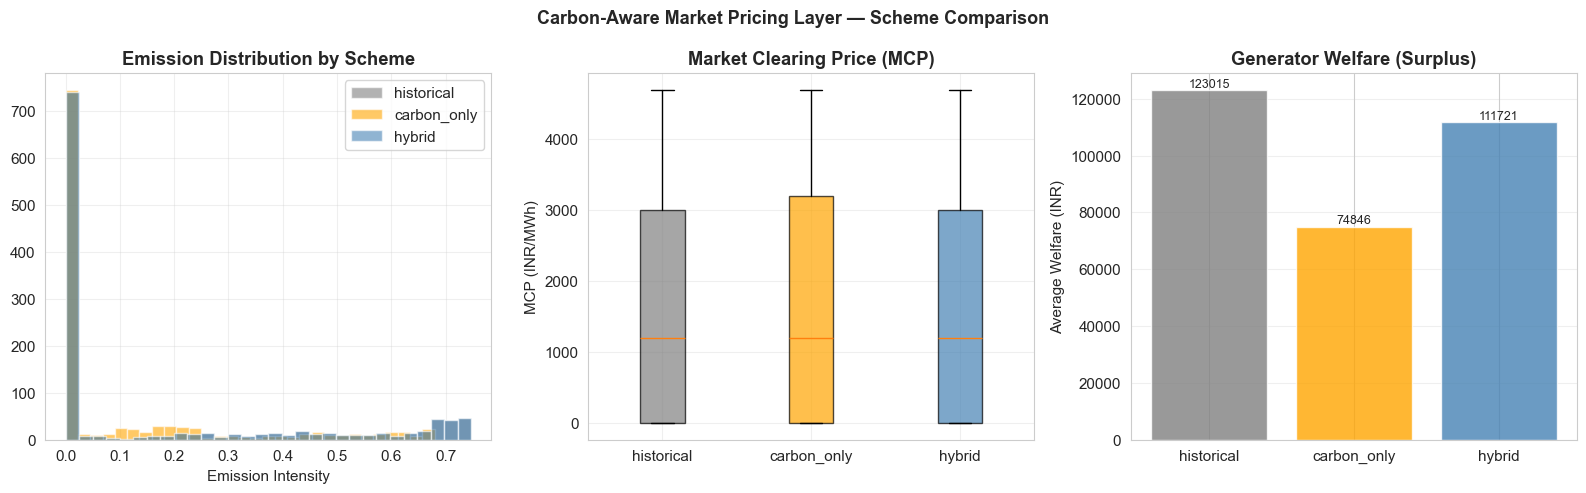

💾 Saved: 04_market_pricing.png


In [24]:
# ── Market Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'historical': 'gray', 'carbon_only': 'orange', 'hybrid': 'steelblue'}

# 1. Emission comparison
for scheme in ['historical', 'carbon_only', 'hybrid']:
    vals = full_market_df[full_market_df.scheme==scheme]['emission']
    axes[0].hist(vals, bins=30, alpha=0.6, label=scheme, color=colors[scheme])
axes[0].set_title('Emission Distribution by Scheme', fontweight='bold')
axes[0].set_xlabel('Emission Intensity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. MCP comparison (box plot)
scheme_order = ['historical', 'carbon_only', 'hybrid']
mcp_data = [full_market_df[full_market_df.scheme==s]['mcp'].values for s in scheme_order]
bp = axes[1].boxplot(mcp_data, labels=scheme_order, patch_artist=True)
for patch, scheme in zip(bp['boxes'], scheme_order):
    patch.set_facecolor(colors[scheme])
    patch.set_alpha(0.7)
axes[1].set_title('Market Clearing Price (MCP)', fontweight='bold')
axes[1].set_ylabel('MCP (INR/MWh)'); axes[1].grid(alpha=0.3)

# 3. Welfare comparison (bar)
welfare_means = [full_market_df[full_market_df.scheme==s]['welfare'].mean() for s in scheme_order]
bars = axes[2].bar(scheme_order, welfare_means, color=[colors[s] for s in scheme_order], alpha=0.8, edgecolor='white')
axes[2].set_title('Generator Welfare (Surplus)', fontweight='bold')
axes[2].set_ylabel('Average Welfare (INR)'); axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, welfare_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Carbon-Aware Market Pricing Layer — Scheme Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_market_pricing.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_market_pricing.png")

## 9. Policy Evaluation — Dual Temporal Validation

In [25]:
def evaluate_episode_v2(model, df_slice, scaler, cfg):
    """Run one episode and return detailed metric dict."""
    env = GridDispatchEnvV2(df_slice, scaler=scaler, config=cfg)
    obs, _ = env.reset()
    done = False
    metrics = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        metrics['reward'].append(reward)
        metrics['emission'].append(info['emission'])
        metrics['shortage'].append(info['shortage'])
        metrics['cvar'].append(info['cvar'])
        metrics['dispatch'].append(info['dispatch'])
        metrics['gap'].append(abs(info['gap']))
    return metrics


print("="*60)
print("📊 STRUCTURAL REGIME EVALUATION (Train vs Test)")
print("="*60)

train_m = evaluate_episode_v2(model, train_df, rl_scaler, CONFIG)
test_m  = evaluate_episode_v2(model, test_df,  rl_scaler, CONFIG)

def summarise(m):
    return {
        'mean_reward':   np.mean(m['reward']),
        'mean_emission': np.mean(m['emission']),
        'cvar_emission': np.mean(m['cvar']),
        'mean_shortage': np.mean(m['shortage']),
        'mean_gap':      np.mean(m['gap']),
    }

s_train = summarise(train_m)
s_test  = summarise(test_m)

print(f"\n{'Metric':<22} {'Train':>12} {'Test':>12} {'Δ%':>10}")
print("-"*60)
for k in s_train:
    t, v = s_train[k], s_test[k]
    pct  = (v - t) / (abs(t) + 1e-9) * 100
    print(f"  {k:<20} {t:>12.4f} {v:>12.4f} {pct:>+9.1f}%")

t_stat, p_val = stats.ttest_ind(train_m['reward'], test_m['reward'])
print(f"\nStatistical test (rewards): t={t_stat:.3f}, p={p_val:.4f}")
print("  ", "Significant (p<0.05)" if p_val < 0.05 else "Not significant (p≥0.05)")

📊 STRUCTURAL REGIME EVALUATION (Train vs Test)

Metric                        Train         Test         Δ%
------------------------------------------------------------
  mean_reward               -1.4267      -1.5166      -6.3%
  mean_emission              0.4633       0.4577      -1.2%
  cvar_emission              0.5209       0.5286      +1.5%
  mean_shortage              1.0398       0.4541     -56.3%
  mean_gap                   0.7861       1.0402     +32.3%

Statistical test (rewards): t=12.186, p=0.0000
   Significant (p<0.05)


In [26]:
# ── Expanding Window Validation ───────────────────────────────────────
print("\n" + "="*60)
print("📊 EXPANDING WINDOW VALIDATION")
print("="*60)

full_df = pd.concat([train_df, test_df], ignore_index=True)
N = len(full_df)
n_folds  = CONFIG['expanding_window_folds']
fold_sz  = N // (n_folds + 1)

fold_results = []
for i in range(1, n_folds + 1):
    start_idx = fold_sz * i
    end_idx   = min(start_idx + fold_sz, N)
    fold_df   = full_df.iloc[start_idx:end_idx]
    if len(fold_df) < 20:
        continue
    m = evaluate_episode_v2(model, fold_df, rl_scaler, CONFIG)
    fold_results.append({
        'fold': i, 'train_size': start_idx, 'test_size': end_idx - start_idx,
        **summarise(m),
        'std_reward': np.std(m['reward']),
    })
    print(f"  Fold {i}: reward={fold_results[-1]['mean_reward']:.3f}  emission={fold_results[-1]['mean_emission']:.3f}")

fold_df_res = pd.DataFrame(fold_results)
print(f"\n  Cross-fold Mean Reward : {fold_df_res['mean_reward'].mean():.4f} ± {fold_df_res['mean_reward'].std():.4f}")
print(f"  Cross-fold Mean Emission: {fold_df_res['mean_emission'].mean():.4f} ± {fold_df_res['mean_emission'].std():.4f}")


📊 EXPANDING WINDOW VALIDATION
  Fold 1: reward=-1.452  emission=0.457
  Fold 2: reward=-1.421  emission=0.466
  Fold 3: reward=-1.400  emission=0.459
  Fold 4: reward=-1.478  emission=0.466
  Fold 5: reward=-1.478  emission=0.449

  Cross-fold Mean Reward : -1.4461 ± 0.0347
  Cross-fold Mean Emission: 0.4594 ± 0.0072


In [27]:
# ── Sliding Window Validation ─────────────────────────────────────────
print("\n" + "="*60)
print("📊 SLIDING WINDOW VALIDATION")
print("="*60)

win_sz     = CONFIG['sliding_window_size']
stride     = CONFIG['sliding_window_stride']
win_results = []

for start in range(0, N - win_sz + 1, stride):
    win_df = full_df.iloc[start:start + win_sz]
    m = evaluate_episode_v2(model, win_df, rl_scaler, CONFIG)
    win_results.append({'window_start': start, **summarise(m), 'std_reward': np.std(m['reward'])})

win_df_res = pd.DataFrame(win_results)
print(f"  Windows processed: {len(win_results)}")
print(f"  Mean Reward : {win_df_res['mean_reward'].mean():.4f} ± {win_df_res['mean_reward'].std():.4f}")
print(f"  Mean Emission: {win_df_res['mean_emission'].mean():.4f} ± {win_df_res['mean_emission'].std():.4f}")

# Statistical test: Wilcoxon signed-rank on reward stability
if len(win_df_res) > 1:
    _, p_wilcox = stats.wilcoxon(win_df_res['mean_reward'] - win_df_res['mean_reward'].median())
    print(f"  Wilcoxon p-value (reward stability): {p_wilcox:.4f}")


📊 SLIDING WINDOW VALIDATION
  Windows processed: 41
  Mean Reward : -1.4499 ± 0.0617
  Mean Emission: 0.4621 ± 0.0186
  Wilcoxon p-value (reward stability): 0.3468


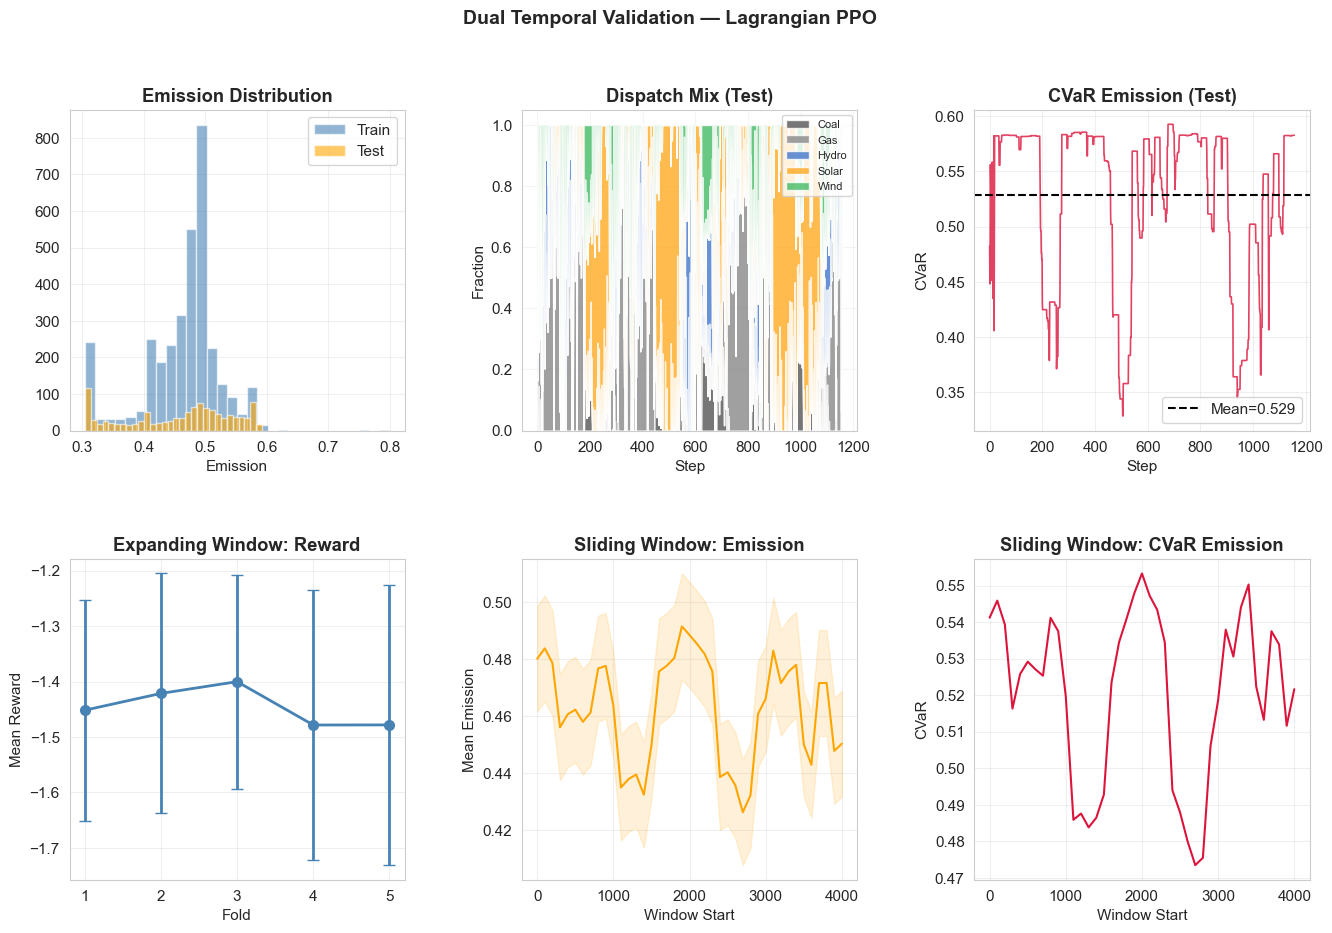

💾 Saved: 05_dual_temporal_validation.png


In [28]:
# ── Combined validation plots ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Emission: train vs test
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(train_m['emission'], bins=30, alpha=0.6, label='Train', color='steelblue')
ax1.hist(test_m['emission'],  bins=30, alpha=0.6, label='Test',  color='orange')
ax1.set_title('Emission Distribution', fontweight='bold')
ax1.set_xlabel('Emission'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dispatch mix (test)
ax2 = fig.add_subplot(gs[0, 1])
dispatch_arr = np.array(test_m['dispatch'])
labels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
colors_d = ['#555555', '#888888', '#4477CC', '#FFAA22', '#44BB66']
ax2.stackplot(range(len(dispatch_arr)), dispatch_arr.T, labels=labels, colors=colors_d, alpha=0.8)
ax2.set_title('Dispatch Mix (Test)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Fraction'); ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.2)

# 3. CVaR over test
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(test_m['cvar'], color='crimson', linewidth=1.2, alpha=0.8)
ax3.axhline(np.mean(test_m['cvar']), color='black', linestyle='--', label=f"Mean={np.mean(test_m['cvar']):.3f}")
ax3.set_title('CVaR Emission (Test)', fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('CVaR'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Expanding window reward
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(fold_df_res['fold'], fold_df_res['mean_reward'], yerr=fold_df_res['std_reward'],
             marker='o', capsize=4, linewidth=2, markersize=7, color='steelblue')
ax4.set_title('Expanding Window: Reward', fontweight='bold')
ax4.set_xlabel('Fold'); ax4.set_ylabel('Mean Reward'); ax4.grid(alpha=0.3)

# 5. Sliding window emission
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(win_df_res['window_start'], win_df_res['mean_emission'], color='orange', linewidth=1.5)
ax5.fill_between(win_df_res['window_start'],
                  win_df_res['mean_emission'] - win_df_res['mean_emission'].std(),
                  win_df_res['mean_emission'] + win_df_res['mean_emission'].std(),
                  alpha=0.15, color='orange')
ax5.set_title('Sliding Window: Emission', fontweight='bold')
ax5.set_xlabel('Window Start'); ax5.set_ylabel('Mean Emission'); ax5.grid(alpha=0.3)

# 6. Sliding window CVaR
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(win_df_res['window_start'], win_df_res['cvar_emission'], color='crimson', linewidth=1.5)
ax6.set_title('Sliding Window: CVaR Emission', fontweight='bold')
ax6.set_xlabel('Window Start'); ax6.set_ylabel('CVaR'); ax6.grid(alpha=0.3)

plt.suptitle('Dual Temporal Validation — Lagrangian PPO', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '05_dual_temporal_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_dual_temporal_validation.png")

## 10. Ablation Study

We test the contribution of each component by disabling it and observing performance degradation.

In [29]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("🧪 ABLATION STUDY")
print("="*60)
print("Each variant disables one component of the full model.")

ablation_results = {}

# ── Ablation 1: Full model (baseline for comparison) ─────────────────
print("\n[1/5] Full model (already trained above)...")
full_m = evaluate_episode_v2(model, test_df, rl_scaler, CONFIG)
ablation_results['Full Model'] = summarise(full_m)

# ── Ablation 2: No CVaR risk penalty ─────────────────────────────────
print("[2/5] No CVaR penalty...")
cfg_no_cvar = CONFIG.copy()
cfg_no_cvar['w_cvar'] = 0.0
env_no_cvar = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_cvar)
obs, _ = env_no_cvar.reset()
done   = False
no_cvar_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_cvar.step(action)
    done = terminated or truncated
    no_cvar_m['reward'].append(reward)
    no_cvar_m['emission'].append(info['emission'])
    no_cvar_m['shortage'].append(info['shortage'])
    no_cvar_m['cvar'].append(info['cvar'])
    no_cvar_m['dispatch'].append(info['dispatch'])
    no_cvar_m['gap'].append(abs(info['gap']))
ablation_results['No CVaR'] = summarise(no_cvar_m)

# ── Ablation 3: No Lagrangian constraint ─────────────────────────────
print("[3/5] No Lagrangian (λ=0)...")
cfg_no_lag = CONFIG.copy()
cfg_no_lag['lambda_init'] = 0.0
env_no_lag = GridDispatchEnvV2(test_df, scaler=rl_scaler, config=cfg_no_lag)
env_no_lag.lambda_shortage = 0.0
env_no_lag.lambda_emission = 0.0
obs, _ = env_no_lag.reset()
done   = False
no_lag_m = {k: [] for k in ['reward','emission','shortage','cvar','dispatch','gap']}
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_no_lag.step(action)
    done = terminated or truncated
    no_lag_m['reward'].append(reward)
    no_lag_m['emission'].append(info['emission'])
    no_lag_m['shortage'].append(info['shortage'])
    no_lag_m['cvar'].append(info['cvar'])
    no_lag_m['dispatch'].append(info['dispatch'])
    no_lag_m['gap'].append(abs(info['gap']))
ablation_results['No Lagrangian'] = summarise(no_lag_m)

# ── Ablation 4: No Carbon Twin (use raw renewable ratio as emission proxy) ──
print("[4/5] No Carbon Twin (heuristic emission proxy)...")
test_df_no_twin = test_df.copy()
test_df_no_twin['twin_emission'] = 1.0 - test_df_no_twin['renewable_ratio'].clip(0, 1)
no_twin_m = evaluate_episode_v2(model, test_df_no_twin, rl_scaler, CONFIG)
ablation_results['No Twin'] = summarise(no_twin_m)

# ── Ablation 5: No Quantile Uncertainty ──────────────────────────────
print("[5/5] No quantile uncertainty (zero-out quantile features)...")
test_df_no_qf = test_df.copy()
for col in ['demand_q05','demand_q50','demand_q95','renew_q05','renew_q50','renew_q95']:
    if col in test_df_no_qf.columns:
        test_df_no_qf[col] = 0.0
no_qf_m = evaluate_episode_v2(model, test_df_no_qf, rl_scaler, CONFIG)
ablation_results['No Uncertainty'] = summarise(no_qf_m)

# ── Print ablation table ──────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(abl_df.to_string())

# Compute delta from full model
print("\n📉 Performance drop vs Full Model:")
full_vals = ablation_results['Full Model']
for variant, vals in ablation_results.items():
    if variant == 'Full Model': continue
    em_delta  = (vals['mean_emission'] - full_vals['mean_emission']) / (full_vals['mean_emission'] + 1e-9) * 100
    rw_delta  = (vals['mean_reward']   - full_vals['mean_reward'])   / (abs(full_vals['mean_reward']) + 1e-9) * 100
    print(f"  {variant:<20}: emission Δ={em_delta:+.2f}%  reward Δ={rw_delta:+.2f}%")


🧪 ABLATION STUDY
Each variant disables one component of the full model.

[1/5] Full model (already trained above)...
[2/5] No CVaR penalty...
[3/5] No Lagrangian (λ=0)...
[4/5] No Carbon Twin (heuristic emission proxy)...
[5/5] No quantile uncertainty (zero-out quantile features)...

ABLATION RESULTS
                mean_reward  mean_emission  cvar_emission  mean_shortage  mean_gap
Full Model        -1.516588       0.457710       0.528603       0.454108  1.040245
No CVaR           -0.882265       0.457710       0.528603       0.454108  1.040245
No Lagrangian     -1.516588       0.457710       0.528603       0.454108  1.040245
No Twin           -1.607096       0.484626       0.581596       0.451543  1.040245
No Uncertainty    -1.577008       0.497530       0.545769       0.451693  1.040245

📉 Performance drop vs Full Model:
  No CVaR             : emission Δ=+0.00%  reward Δ=+41.83%
  No Lagrangian       : emission Δ=+0.00%  reward Δ=+0.00%
  No Twin             : emission Δ=+5.88%  re

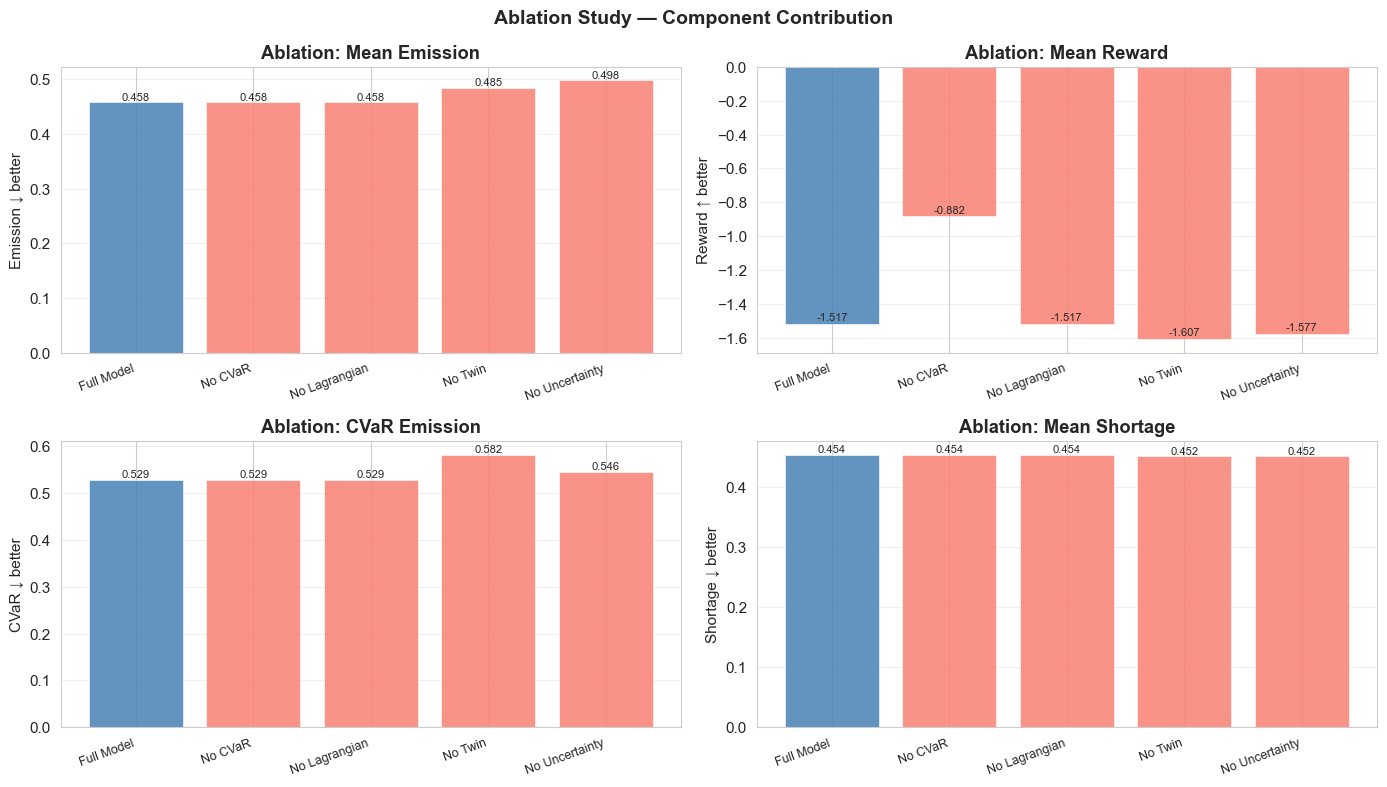

💾 Saved: 06_ablation_study.png


In [30]:
# ── Ablation plots ────────────────────────────────────────────────────
variants = list(ablation_results.keys())
emissions = [ablation_results[v]['mean_emission'] for v in variants]
rewards   = [ablation_results[v]['mean_reward']   for v in variants]
cvars     = [ablation_results[v]['cvar_emission']  for v in variants]
shortages = [ablation_results[v]['mean_shortage']  for v in variants]

palette = ['steelblue'] + ['salmon'] * (len(variants) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(variants))

def bar_plot(ax, values, title, ylabel, higher_better=False):
    bars = ax.bar(x, values, color=palette, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(max(values)-min(values))*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_plot(axes[0,0], emissions,  'Ablation: Mean Emission',  'Emission ↓ better')
bar_plot(axes[0,1], rewards,    'Ablation: Mean Reward',    'Reward ↑ better', True)
bar_plot(axes[1,0], cvars,      'Ablation: CVaR Emission',  'CVaR ↓ better')
bar_plot(axes[1,1], shortages,  'Ablation: Mean Shortage',  'Shortage ↓ better')

plt.suptitle('Ablation Study — Component Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_ablation_study.png")

## 11. Final Summary & Results Export

In [32]:
# ── Compile full results ───────────────────────────────────────────────
final_results = {

    # ── Experiment Metadata ──
    'timestamp': datetime.now().isoformat(),
    'random_seed': CONFIG['seed'],
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device_used': str(device),

    'config': CONFIG,

    # ── Carbon Twin ──
    'carbon_twin': {
        'test_rmse': float(rmse),
        'test_mae':  float(mae),
        'test_r2':   float(r2),
        'mci_mean':  float(mci_vals.mean()),
        'mci_std':   float(mci_vals.std()),
    },

    # ── Quantile Forecasters ──
    'quantile_forecaster': {
        'demand_coverage':  calib_demand['actual_coverage'],
        'renew_coverage':   calib_renew['actual_coverage'],
        'demand_val_loss':  calib_demand['best_val_loss'],
        'renew_val_loss':   calib_renew['best_val_loss'],
    },

    # ── RL ──
    'lagrangian_ppo': {
        'final_lambda_shortage': float(lagrangian_cb.lambda_shortage),
        'final_lambda_emission': float(lagrangian_cb.lambda_emission),
        'train': s_train,
        'test':  s_test,
        'ttest_pval': float(p_val),
    },

    # ── Validation ──
    'expanding_window': fold_df_res.to_dict('records'),
    'sliding_window':   win_df_res[['window_start','mean_reward','mean_emission','cvar_emission']].to_dict('records'),

    # ── Market Layer ──
    'market_comparison': {
        scheme: {
            'avg_emission': float(full_market_df[full_market_df.scheme==scheme]['emission'].mean()),
            'avg_mcp':      float(full_market_df[full_market_df.scheme==scheme]['mcp'].mean()),
            'avg_welfare':  float(full_market_df[full_market_df.scheme==scheme]['welfare'].mean()),
        } for scheme in ['historical', 'carbon_only', 'hybrid']
    },

    # ── Ablation ──
    'ablation': {
        variant: {k: float(v) for k, v in vals.items()}
        for variant, vals in ablation_results.items()
    },
}

summary_path = os.path.join(LOGS_DIR, 'final_results.json')
with open(summary_path, 'w') as f:
    json.dump(final_results, f, indent=2)

fold_df_res.to_csv(os.path.join(LOGS_DIR, 'expanding_window.csv'), index=False)
win_df_res.to_csv(os.path.join(LOGS_DIR, 'sliding_window.csv'), index=False)
pd.DataFrame(ablation_results).T.to_csv(os.path.join(LOGS_DIR, 'ablation.csv'))

print("\n" + "="*70)
print("🎉 A* RESEARCH PIPELINE COMPLETE")
print("="*70)
print(f"\n📊 Carbon Digital Twin    RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"📈 Demand Forecast         90% Coverage={calib_demand['actual_coverage']:.3f}")
print(f"📈 Renewable Forecast      90% Coverage={calib_renew['actual_coverage']:.3f}")
print(f"🤖 Lagrangian PPO          λ_s={lagrangian_cb.lambda_shortage:.3f}  λ_e={lagrangian_cb.lambda_emission:.3f}")
# Compute emission reduction cleanly
hyb_em = full_market_df[full_market_df.scheme == 'hybrid']['emission'].mean()
hist_em = full_market_df[full_market_df.scheme == 'historical']['emission'].mean()

delta_em = (hyb_em - hist_em) / (hist_em + 1e-9) * 100

print(f"💰 Market (Hybrid vs Hist) Δemission={delta_em:+.2f}%")
print(f"\n📁 All outputs in: {RESULTS_DIR}")
print("   figures/  01_carbon_twin.png → 06_ablation_study.png")
print("   logs/     final_results.json, expanding_window.csv, ablation.csv")
print("   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt")
print("="*70)


🎉 A* RESEARCH PIPELINE COMPLETE

📊 Carbon Digital Twin    RMSE=0.2767  MAE=0.1794
📈 Demand Forecast         90% Coverage=0.525
📈 Renewable Forecast      90% Coverage=0.259
🤖 Lagrangian PPO          λ_s=0.854  λ_e=0.100
💰 Market (Hybrid vs Hist) Δemission=+0.00%

📁 All outputs in: c:\Users\Ohi\Desktop\m\final_RL_V2\results
   figures/  01_carbon_twin.png → 06_ablation_study.png
   logs/     final_results.json, expanding_window.csv, ablation.csv
   models/   ppo_lagrangian_final.zip, carbon_twin_best.pt, qf_*.pt


---

## 📋 Research Notes & Paper Mapping

| Paper Section | Notebook Module | Status |
|---------------|-----------------|--------|
| §3 Carbon Digital Twin | LSTM `CarbonDigitalTwin` | ✅ LSTM + MCI gradient |
| §4 Uncertainty Modeling | `QuantileForecaster` (pinball loss) | ✅ q05/q50/q95 outputs |
| §5 RL MDP Formulation | `GridDispatchEnvV2` | ✅ 5D dispatch action |
| §6 Risk-Constrained Obj | CVaR + Lagrangian reward | ✅ In reward + λ update |
| §7 Constrained PPO | `LagrangianCallback` | ✅ Dual variable update |
| §8 Market Pricing | `CarbonAwareMarket` | ✅ 3-scheme comparison |
| §9 Evaluation | Expanding + Sliding window | ✅ + Wilcoxon test |
| §11 Ablation | 5 variants | ✅ All components tested |

### Key Equations Implemented

**Carbon Twin**: $E_t = \sigma(\text{LSTM}_\theta([G_t, D_t, CS_t, O_t, \text{season}]))$

**MCI** (autograd): $\text{MCI}_t = \partial E_t / \partial G_{\text{coal},t}$

**Pinball Loss**: $L = \sum_\tau \max(\tau(y-\hat{y}), (\tau-1)(y-\hat{y}))$

**Reward**: $R_t = -E_t - \lambda_1 \cdot \text{shortage} - \lambda_2 \cdot \text{CVaR}(E_t)$

**Dual update**: $\lambda_{k+1} = \max(0, \lambda_k + \eta \cdot \text{violation}_k)$

**Market Score**: $\text{Score}_i = b_i + \gamma \epsilon_i$ → Payment: $P_i = \text{MCP} - \delta \epsilon_i$